# 🎓 Machine Learning — Logistic Regression Complete Guide

> **A premium university-grade course combined with an interactive coding tutorial.**

Welcome! This notebook takes you on a complete journey — from *"What is classification?"* all the way to building, evaluating, and interpreting a **Logistic Regression** model from scratch **and** with `scikit-learn`.

Despite its name, **Logistic Regression is a CLASSIFICATION algorithm**, not a regression algorithm. It is the natural companion to Linear Regression — once you understand both, you understand the foundation of all supervised learning.

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** what classification is and where Logistic Regression fits in the ML landscape.
2. **Differentiate** between binary and multi-class classification.
3. **Develop strong intuition** for the sigmoid function and decision boundaries.
4. **Derive** the binary cross-entropy cost function and the gradient descent update rules step-by-step.
5. **Implement** Logistic Regression from scratch using **only NumPy and Matplotlib**.
6. **Use** `scikit-learn`'s `LogisticRegression` confidently for binary and multi-class problems.
7. **Preprocess** real-world classification datasets (encoding, scaling, imbalance handling).
8. **Evaluate** classifiers using Accuracy, Precision, Recall, F1, ROC-AUC, and Confusion Matrix.
9. **Apply** Regularization (L1, L2, ElasticNet) and understand the `C` parameter.
10. **Handle** multi-class classification (One-vs-Rest, Multinomial/Softmax).
11. **Build** an end-to-end practical classification project.
12. **Answer** 55+ interview questions with confidence.

---

## 📋 Prerequisites

| Skill | Level Needed |
|-------|-------------|
| Python basics | Comfortable with variables, loops, functions, lists, dicts |
| NumPy | Basic array operations |
| Matplotlib | Basic plotting |
| Pandas | Helpful but not mandatory |
| Mathematics | High-school algebra + basic calculus (derivatives) |
| Linear Regression | Strongly recommended — Logistic Regression builds on it |

> 💡 **Note:** If you haven't completed the Linear Regression notebook yet, we recommend doing so first — many concepts (cost functions, gradient descent, regularization) carry over directly.

---

## 📊 Dataset Overview

Throughout this notebook we use **five** datasets to keep things interesting:

| # | Dataset | Type | Classes | Source |
|---|---------|------|---------|--------|
| 1 | **Synthetic Binary** (2 blobs) | Synthetic | 2 | Generated with NumPy |
| 2 | **Exam Pass/Fail** | Synthetic | 2 | Generated (study hours → pass) |
| 3 | **Iris** (flower species) | Real-world | 3 | `sklearn.datasets.load_iris()` |
| 4 | **Breast Cancer** | Real-world | 2 | `sklearn.datasets.load_breast_cancer()` |
| 5 | **Digits** (0-9) | Real-world | 10 | `sklearn.datasets.load_digits()` |

We generate synthetic data where needed and use `sklearn.datasets` where available — **no external downloads required**.

---

## 📑 Table of Contents

| Part | Title |
|------|-------|
| 1 | Introduction to Classification |
| 2 | Understanding Classification |
| 3 | Intuition Behind Logistic Regression |
| 4 | Mathematics of Logistic Regression |
| 5 | The Cost Function (Cross-Entropy) |
| 6 | Optimization |
| 7 | Gradient Descent for Logistic Regression |
| 8 | Mathematical Derivation |
| 9 | From-Scratch Implementation |
| 10 | scikit-learn Implementation |
| 11 | Datasets |
| 12 | Data Preprocessing for Classification |
| 13 | Assumptions & Properties of Logistic Regression |
| 14 | Evaluation Metrics for Classification |
| 15 | Regularization (L1 / L2 / ElasticNet) |
| 16 | Decision Boundaries & Non-Linear Features |
| 17 | Comprehensive Visualization |
| 18 | Practical End-to-End Project |
| 19 | Interview Questions (55+) |
| 20 | Common Mistakes |
| 21 | Summary & Cheat Sheet |
| 22 | Exercises |
| 23 | Further Reading |

---

> ⚠️ **Important:** Run the cells **in order**. Many later cells depend on earlier imports and variables.


In [1]:
# ============================================================
# Core Imports — Run this cell first!
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ All imports successful. Let's begin!")


✅ All imports successful. Let's begin!


# Part 1: Introduction to Classification

---

## 1.1 What is Classification?

**Classification** is a supervised learning task where the model predicts which **category (class)** an input belongs to.

> 🧠 **Analogy — Sorting mail:**
> - **Regression** (previous notebook): Predict the *weight* of a package → a continuous number.
> - **Classification** (this notebook): Predict whether a package is *fragile* or *not fragile* → a category.

### Formal Definition:

Given training data with labeled examples:
$$(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$$
where each $y_i \in \{C_1, C_2, \dots, C_K\}$ is a **discrete class label**, learn a function $f$ such that $f(x) \approx y$ for new inputs.

### Examples of Classification Tasks:

| Task | Input | Output (Classes) |
|------|-------|------------------|
| Email spam filter | Email text | Spam / Not Spam |
| Medical diagnosis | Patient symptoms | Disease / No Disease |
| Image recognition | Image pixels | Cat / Dog / Bird / ... |
| Credit approval | Applicant info | Approved / Denied |
| Sentiment analysis | Review text | Positive / Negative / Neutral |
| Face recognition | Face image | Person A / B / C / ... |

## 1.2 Types of Classification

| Type | # Classes | Example |
|------|-----------|---------|
| **Binary** | 2 | Spam / Not Spam |
| **Multi-class** | 3+ (mutually exclusive) | Digit recognition (0-9) |
| **Multi-label** | Multiple labels at once | Tagging (a movie can be Action + Comedy) |

> 📌 **Logistic Regression** naturally handles **binary** classification. We'll see how to extend it to **multi-class** later (One-vs-Rest, Softmax).

## 1.3 Where Does Logistic Regression Fit?

```
Machine Learning
└── Supervised Learning
    ├── Regression      (continuous output)  → Linear Regression
    └── Classification  (discrete output)    → Logistic Regression ← here!
```

### Why "Logistic Regression" and not "Logistic Classification"?

The name is historical:
- The model **regresses the probability** of belonging to a class (a continuous value between 0 and 1).
- It then **thresholds** that probability to make a class prediction.
- So it's "regression of a probability" used for "classification".

## 1.4 Why is Logistic Regression So Important?

### 1. 🏗️ **Conceptual Foundation**
Logistic Regression introduces the **sigmoid function**, **cross-entropy loss**, and **maximum likelihood** — concepts that power neural networks and deep learning.

### 2. 📖 **Interpretability**
Coefficients have a clear meaning: *"How much does the log-odds of the positive class change when feature $x_j$ increases by 1?"* You can even compute odds ratios.

### 3. ⚡ **Speed & Simplicity**
Training takes milliseconds. Inference is a single dot product + sigmoid. Perfect for:
- Real-time systems
- Baseline models
- A/B testing

### 4. 🎯 **Probabilistic Output**
Unlike Decision Trees or SVMs, Logistic Regression gives you a **probability** — not just a class. This is crucial for:
- Risk scoring (credit, insurance)
- Ranking (search results, recommendations)
- Calibration-sensitive applications

### 5. 🧮 **Mathematical Elegance**
Logistic Regression is derived from **Maximum Likelihood Estimation** under the Bernoulli distribution. The cost function (cross-entropy) is **convex** — guaranteed global minimum.

### 6. 🔗 **The Building Block of Neural Networks**
A single-layer neural network with sigmoid activation **is** Logistic Regression. Master this, and you're 80% of the way to understanding deep learning.

---

### 📝 Part 1 Summary

| Concept | Key Idea |
|---------|----------|
| Classification | Predicting discrete categories |
| Binary classification | 2 classes (spam/not spam) |
| Multi-class | 3+ mutually exclusive classes |
| Logistic Regression | Classification via regressed probabilities |
| Why important? | Foundation, interpretable, probabilistic |

### ✅ Key Takeaways
- Classification predicts categories; regression predicts numbers.
- Logistic Regression is a **classification** algorithm (despite its name).
- It outputs probabilities, then thresholds them into classes.
- It's the gateway to neural networks.

### ⚠️ Common Mistakes
- Thinking Logistic Regression is for regression (it's for classification!).
- Confusing multi-class with multi-label.
- Forgetting that Logistic Regression outputs probabilities, not just labels.

### 📝 Practice Questions
1. Give an example of a binary classification task in healthcare.
2. Why is Logistic Regression called "regression" if it does classification?
3. What's the difference between multi-class and multi-label classification?


# Part 2: Understanding Classification

---

## 2.1 The Classification Problem

Given a set of features $\mathbf{x}$, predict a class label $y \in \{0, 1, \dots, K-1\}$.

### Binary Classification (K=2):
- Labels: $y \in \{0, 1\}$
- Common convention: 1 = "positive class", 0 = "negative class"
- Examples: 1=spam, 0=ham | 1=disease, 0=healthy | 1=click, 0=no-click

### Multi-Class Classification (K>2):
- Labels: $y \in \{0, 1, 2, \dots, K-1\}$
- Classes are **mutually exclusive** (an input belongs to exactly one class)
- Examples: digits 0-9, flower species, animal categories

## 2.2 Why Not Just Use Linear Regression for Classification?

Great question! Why not fit a line and threshold at 0.5?

### Problem 1: Linear regression outputs unbounded values
- Linear regression: $\hat{y} = \beta_0 + \beta_1 x$ can be any real number.
- For classification, we want a **probability** in $[0, 1]$.
- A predicted value of -3 or +5 has no probabilistic meaning.

### Problem 2: Linear regression is sensitive to outliers
- A few extreme points can drastically change the line.
- The decision boundary shifts unpredictably.

### Problem 3: Linear regression doesn't model the right thing
- We want $P(y=1 | x)$, not the value of $y$ itself.
- Linear regression minimizes squared error, not the right objective for classification.

### The Solution: Logistic Regression
We need a function that:
1. Takes any real number (from $-\infty$ to $+\infty$)
2. Squashes it into $[0, 1]$
3. Is differentiable (for gradient descent)
4. Has nice statistical properties (for maximum likelihood)

That function is the **sigmoid** (logistic) function — we'll explore it in Part 3.


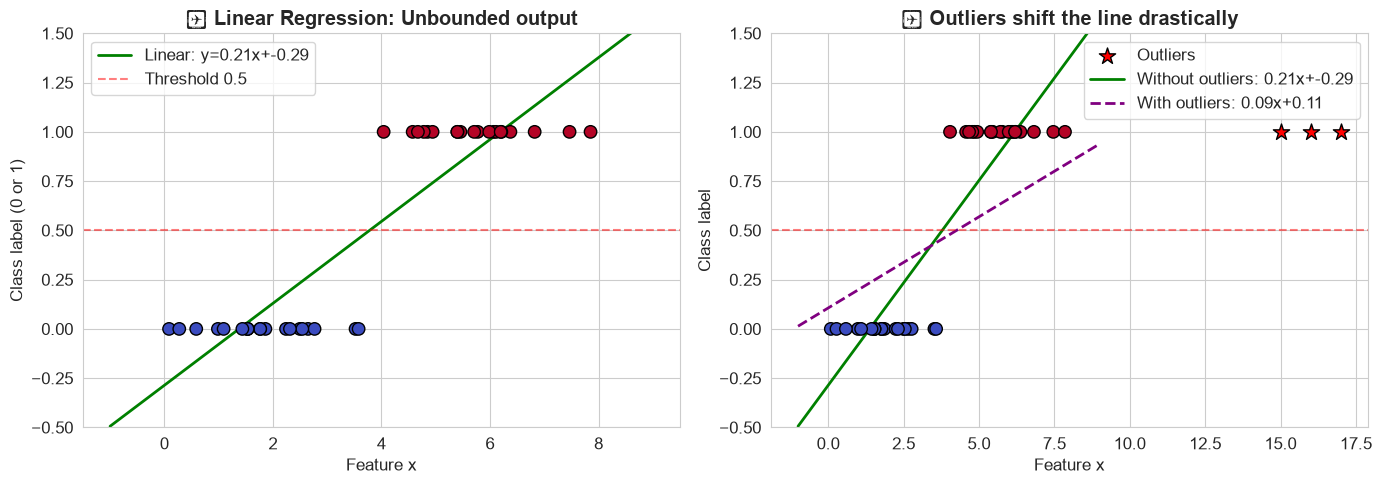

💡 Linear regression is unbounded and outlier-sensitive — bad for classification!
   We need a function that squashes output to [0,1] → the SIGMOID.


In [2]:
# ============================================================
# Visualize: Why Linear Regression Fails for Classification
# ============================================================
np.random.seed(42)

# Generate binary classification data
x_lin_clf = np.concatenate([np.random.normal(2, 1, 20), np.random.normal(6, 1, 20)])
y_lin_clf = np.concatenate([np.zeros(20), np.ones(20)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Linear regression on classification data
axes[0].scatter(x_lin_clf, y_lin_clf, c=y_lin_clf, cmap='coolwarm', s=80, edgecolor='k', zorder=5)
# Fit linear regression
m, c = np.polyfit(x_lin_clf, y_lin_clf, 1)
x_range = np.linspace(-1, 9, 100)
axes[0].plot(x_range, m * x_range + c, 'g-', linewidth=2, label=f'Linear: y={m:.2f}x+{c:.2f}')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold 0.5')
axes[0].set_ylim(-0.5, 1.5)
axes[0].set_xlabel('Feature x')
axes[0].set_ylabel('Class label (0 or 1)')
axes[0].set_title('❌ Linear Regression: Unbounded output', fontweight='bold')
axes[0].legend()

# Right: Add an outlier and show how linear regression shifts
x_with_outlier = np.append(x_lin_clf, [15, 16, 17])
y_with_outlier = np.append(y_lin_clf, [1, 1, 1])
m2, c2 = np.polyfit(x_with_outlier, y_with_outlier, 1)
axes[1].scatter(x_with_outlier[:-3], y_with_outlier[:-3], c=y_with_outlier[:-3], cmap='coolwarm', s=80, edgecolor='k', zorder=5)
axes[1].scatter(x_with_outlier[-3:], y_with_outlier[-3:], c='red', s=150, marker='*', edgecolor='k', zorder=5, label='Outliers')
axes[1].plot(x_range, m * x_range + c, 'g-', linewidth=2, label=f'Without outliers: {m:.2f}x+{c:.2f}')
axes[1].plot(x_range, m2 * x_range + c2, 'purple', linewidth=2, linestyle='--', label=f'With outliers: {m2:.2f}x+{c2:.2f}')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_xlabel('Feature x')
axes[1].set_ylabel('Class label')
axes[1].set_title('❌ Outliers shift the line drastically', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print("💡 Linear regression is unbounded and outlier-sensitive — bad for classification!")
print("   We need a function that squashes output to [0,1] → the SIGMOID.")


## 2.3 Classification vs Regression — Side by Side

| Aspect | **Regression** | **Classification** |
|--------|----------------|-------------------|
| **Output** | Continuous (real numbers) | Discrete (categories) |
| **Output example** | 3.5, 42.0, -1.2 | 0, 1, "spam", "cat" |
| **Question** | "How much?" | "Which class?" |
| **Example task** | Predict house price = $350k | Predict spam = Yes/No |
| **Algorithm** | Linear Regression | Logistic Regression, SVM, KNN, Trees |
| **Cost function** | MSE (squared error) | Cross-Entropy (log loss) |
| **Evaluation** | MSE, RMSE, MAE, R² | Accuracy, Precision, Recall, F1, AUC |
| **Output range** | $(-\infty, +\infty)$ | $[0, 1]$ (probabilities) or class labels |

## 2.4 The Classification Pipeline

```
1. Collect labeled data (X, y) with y ∈ {0, 1, ..., K-1}
2. Preprocess (encode labels, scale features, handle imbalance)
3. Split into train/test
4. Train classifier (learn parameters θ)
5. Predict probabilities: P(y=k | x)
6. Convert probabilities to class labels (argmax or threshold)
7. Evaluate (accuracy, precision, recall, F1, AUC)
```

---

### 📝 Part 2 Summary

| Concept | Key Idea |
|---------|----------|
| Classification | Predicting discrete class labels |
| Binary | 2 classes (0 and 1) |
| Multi-class | 3+ mutually exclusive classes |
| Why not linear regression? | Unbounded, outlier-sensitive, wrong objective |

### ✅ Key Takeaways
- Classification answers "which class?" — regression answers "how much?".
- Linear regression fails for classification because its output is unbounded.
- Logistic Regression squashes output through the sigmoid function to $[0,1]$.
- The right cost function for classification is **cross-entropy**, not MSE.

### ⚠️ Common Mistakes
- Using MSE as the loss for classification (use cross-entropy instead).
- Treating class labels as continuous numbers.
- Forgetting that classification outputs should be probabilities.

### 📝 Practice Questions
1. Name 3 reasons why linear regression is a poor choice for binary classification.
2. What range should a probability be in?
3. Why is the output of linear regression not a valid probability?


# Part 3: Intuition Behind Logistic Regression

---

## 3.1 The Core Idea

> **Logistic Regression models the probability that an input belongs to the positive class, then thresholds that probability to make a decision.**

### The Two-Step Process:

```
Step 1: Compute a "score" z = β₀ + β₁x₁ + ... + βₚxₚ    (linear, like Linear Regression)
Step 2: Squash z through the sigmoid function: σ(z) = 1/(1+e^(-z))   (output in [0,1])
```

The output $\sigma(z)$ is interpreted as $P(y=1 | x)$ — the probability of the positive class.

### Decision Rule:
- If $\sigma(z) \geq 0.5$ → predict class 1
- If $\sigma(z) < 0.5$ → predict class 0

## 3.2 The Sigmoid Function — The Heart of Logistic Regression

The **sigmoid** (also called the **logistic function**) is:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Properties:
| Property | Value |
|----------|-------|
| **Domain** | $(-\infty, +\infty)$ |
| **Range** | $(0, 1)$ |
| **At z=0** | $\sigma(0) = 0.5$ |
| **As z→+∞** | $\sigma(z) → 1$ |
| **As z→-∞** | $\sigma(z) → 0$ |
| **Symmetry** | $\sigma(-z) = 1 - \sigma(z)$ |
| **Derivative** | $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ |

### Why is this perfect for classification?
1. **Bounded:** Always between 0 and 1 → can be interpreted as a probability.
2. **Monotonic:** Larger z → larger probability (preserves ordering).
3. **Smooth:** Differentiable everywhere → works with gradient descent.
4. **Symmetric:** $\sigma(0) = 0.5$ is the natural decision boundary.
5. **Probabilistic:** Output is a genuine probability (under the Bernoulli model).


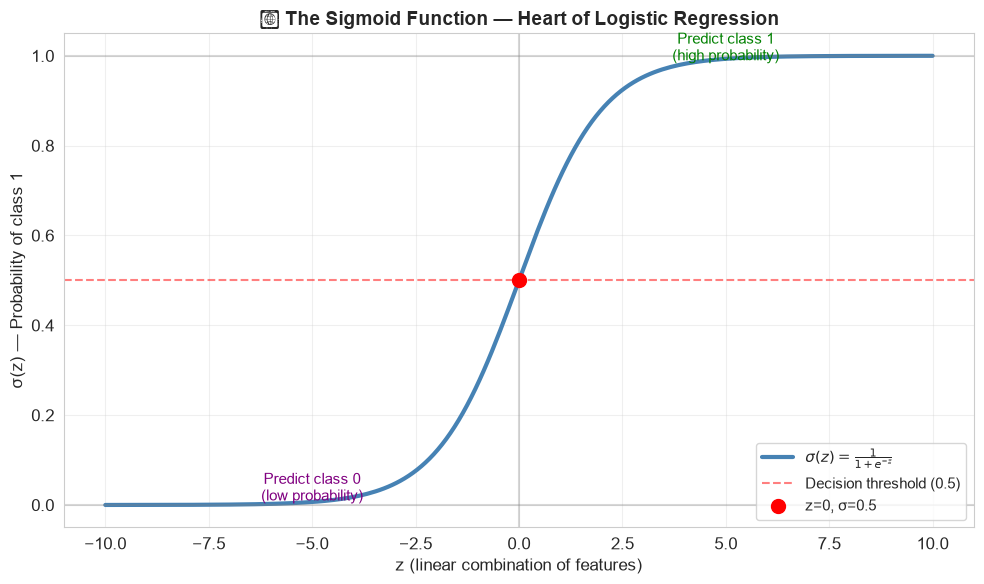

Key observations:
  σ(0) = 0.5000  (boundary)
  σ(5) = 0.9933  (very confident class 1)
  σ(-5) = 0.0067  (very confident class 0)
  σ(10) = 1.0000  (essentially 1)


In [3]:
# ============================================================
# Visualize: The Sigmoid Function
# ============================================================
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid, 'steelblue', linewidth=3, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Decision threshold (0.5)')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
plt.scatter([0], [0.5], color='red', s=100, zorder=5, label='z=0, σ=0.5')

# Annotate
plt.annotate('Predict class 1\n(high probability)', xy=(5, 0.99), fontsize=11, ha='center', color='green')
plt.annotate('Predict class 0\n(low probability)', xy=(-5, 0.01), fontsize=11, ha='center', color='purple')
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) — Probability of class 1')
plt.title('🔵 The Sigmoid Function — Heart of Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  σ(0) = {1/(1+np.exp(0)):.4f}  (boundary)")
print(f"  σ(5) = {1/(1+np.exp(-5)):.4f}  (very confident class 1)")
print(f"  σ(-5) = {1/(1+np.exp(5)):.4f}  (very confident class 0)")
print(f"  σ(10) = {1/(1+np.exp(-10)):.4f}  (essentially 1)")


## 3.3 The Log-Odds (Logit) Interpretation

There's a beautiful mathematical relationship hidden in the sigmoid.

### The Inverse Sigmoid (Logit):
If $p = \sigma(z) = \frac{1}{1+e^{-z}}$, then solving for $z$:

$$z = \ln\left(\frac{p}{1-p}\right)$$

This is the **logit** function, also called **log-odds**.

### Interpretation:
- $\frac{p}{1-p}$ is the **odds** of the positive class (e.g., 3:1 odds means p=0.75).
- $\ln\left(\frac{p}{1-p}\right)$ is the **log-odds**.

### The Logistic Regression Model (Logit Form):

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

> 💡 **Interpretation:** Logistic Regression assumes a **linear relationship between features and the log-odds** of the positive class. This is the key assumption!

### Coefficient Meaning:
A coefficient $\beta_j$ means: *"For a one-unit increase in $x_j$, the log-odds of the positive class increase by $\beta_j$ (holding other features constant)."*

Equivalently, the **odds multiply by $e^{\beta_j}$**.

## 3.4 Example: Exam Pass/Fail Prediction

Let's build intuition with a concrete example.

**Scenario:** Students take an exam. We have their study hours and whether they passed (1) or failed (0).


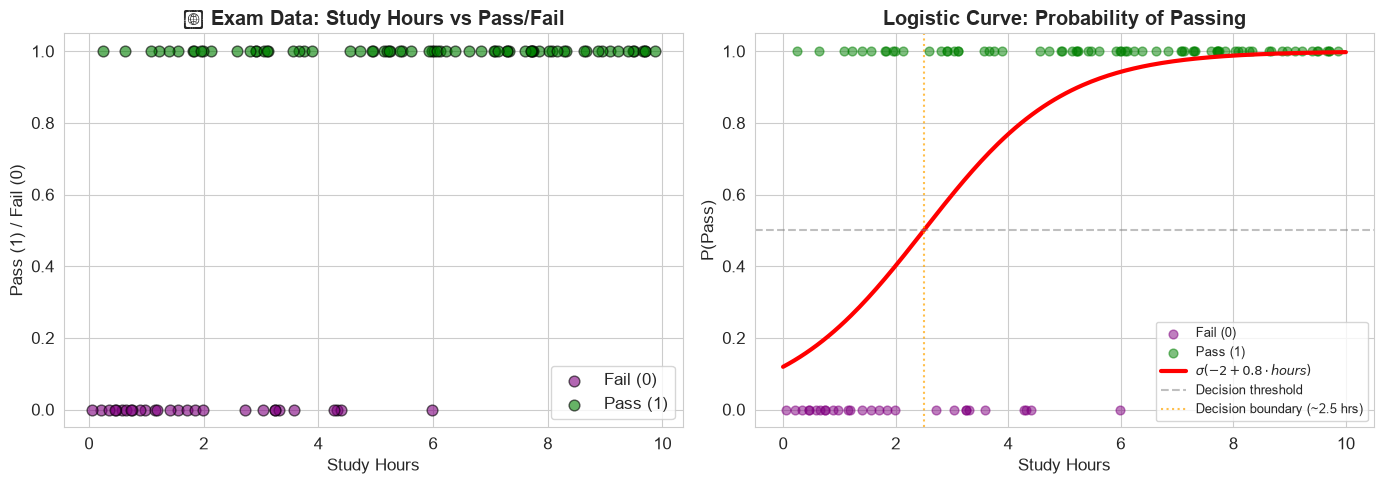

💡 Interpretation:
   - Students studying < 2.5 hours are more likely to FAIL (P<0.5)
   - Students studying > 2.5 hours are more likely to PASS (P>0.5)
   - The curve smoothly transitions from 0 to 1
   - At 5 hours, P(pass) = 0.8810572687224669
   - At 10 hours, P(pass) = 0.998003992015968


In [4]:
# ============================================================
# Example: Exam Pass/Fail based on Study Hours
# ============================================================
np.random.seed(42)

# Generate data: more study hours → higher pass probability
n_students = 100
study_hours = np.random.uniform(0, 10, n_students)
# True relationship: log-odds of pass = -2 + 0.8 * study_hours
log_odds = -2 + 0.8 * study_hours
prob_pass = 1 / (1 + np.exp(-log_odds))
passed = np.random.binomial(1, prob_pass)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter plot of raw data
axes[0].scatter(study_hours[passed==0], passed[passed==0], color='purple', s=60, alpha=0.6, label='Fail (0)', edgecolor='k')
axes[0].scatter(study_hours[passed==1], passed[passed==1], color='green', s=60, alpha=0.6, label='Pass (1)', edgecolor='k')
axes[0].set_xlabel('Study Hours')
axes[0].set_ylabel('Pass (1) / Fail (0)')
axes[0].set_title('📚 Exam Data: Study Hours vs Pass/Fail', fontweight='bold')
axes[0].legend()

# Right: Sigmoid curve fit (approximate using our knowledge of true params)
x_range = np.linspace(0, 10, 200)
true_prob = 1 / (1 + np.exp(-(-2 + 0.8 * x_range)))
axes[1].scatter(study_hours[passed==0], passed[passed==0], color='purple', s=40, alpha=0.5, label='Fail (0)')
axes[1].scatter(study_hours[passed==1], passed[passed==1], color='green', s=40, alpha=0.5, label='Pass (1)')
axes[1].plot(x_range, true_prob, 'r-', linewidth=3, label=r'$\sigma(-2 + 0.8 \cdot hours)$')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision threshold')
axes[1].axvline(x=2.5, color='orange', linestyle=':', alpha=0.7, label='Decision boundary (~2.5 hrs)')
axes[1].set_xlabel('Study Hours')
axes[1].set_ylabel('P(Pass)')
axes[1].set_title('Logistic Curve: Probability of Passing', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("   - Students studying < 2.5 hours are more likely to FAIL (P<0.5)")
print("   - Students studying > 2.5 hours are more likely to PASS (P>0.5)")
print("   - The curve smoothly transitions from 0 to 1")
print("   - At 5 hours, P(pass) =", 1/(1+np.exp(-(-2+0.8*5))).round(3))
print("   - At 10 hours, P(pass) =", 1/(1+np.exp(-(-2+0.8*10))).round(3))


## 3.5 Decision Boundary

The **decision boundary** is the set of points where the model is "undecided" — where $P(y=1|x) = 0.5$.

### For 1D input (one feature):
$$\beta_0 + \beta_1 x = 0 \implies x = -\frac{\beta_0}{\beta_1}$$

In the exam example: $x = -(-2)/0.8 = 2.5$ hours.

### For 2D input (two features):
$$\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0$$

This is a **line** in 2D space — the decision boundary!

### For higher dimensions:
$$\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p = 0$$

This is a **hyperplane** in p-dimensional space.

> 💡 **Key insight:** Logistic Regression has a **linear decision boundary**. If your data isn't linearly separable, you need polynomial features or a different algorithm.


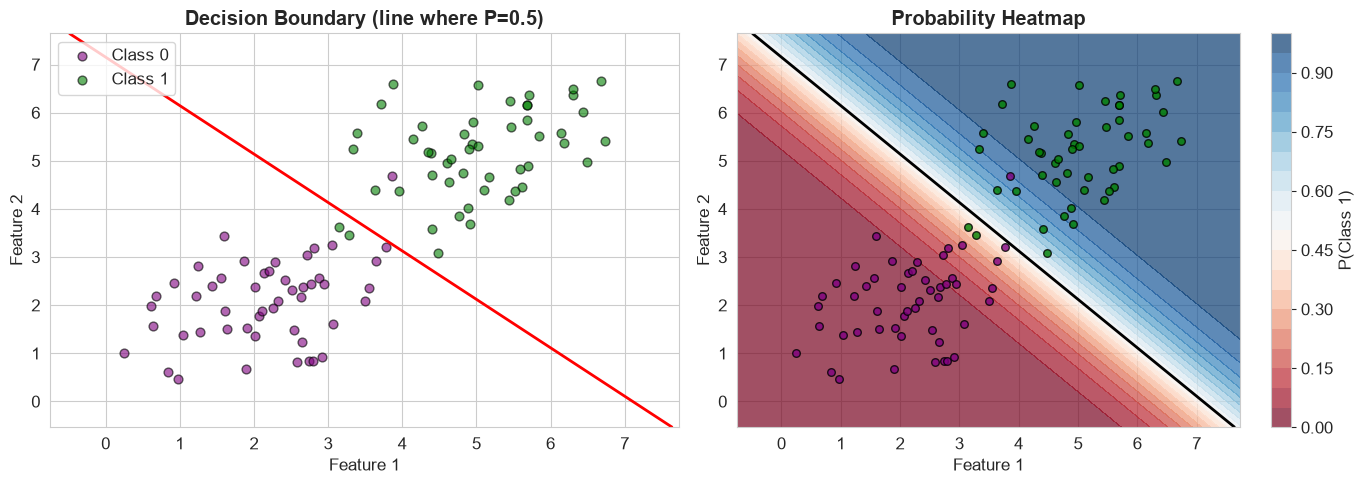

💡 The red/black line is the decision boundary — where P(Class 1) = 0.5
   Points above the line → Class 1, below → Class 0


In [5]:
# ============================================================
# Visualize: Decision Boundary in 2D
# ============================================================
np.random.seed(42)

# Generate 2D binary classification data
n_per_class = 50
X_class0 = np.random.multivariate_normal([2, 2], [[1, 0.5], [0.5, 1]], n_per_class)
X_class1 = np.random.multivariate_normal([5, 5], [[1, 0.5], [0.5, 1]], n_per_class)
X_2d = np.vstack([X_class0, X_class1])
y_2d = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

# Fit logistic regression (using sklearn for now, we'll build our own later)
from sklearn.linear_model import LogisticRegression
log_reg_2d = LogisticRegression()
log_reg_2d.fit(X_2d, y_2d)

# Create mesh for decision boundary
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = log_reg_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Decision boundary (line)
axes[0].contour(xx, yy, Z, levels=[0.5], colors='red', linewidths=2)
axes[0].scatter(X_class0[:, 0], X_class0[:, 1], color='purple', s=40, alpha=0.6, label='Class 0', edgecolor='k')
axes[0].scatter(X_class1[:, 0], X_class1[:, 1], color='green', s=40, alpha=0.6, label='Class 1', edgecolor='k')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Decision Boundary (line where P=0.5)', fontweight='bold')
axes[0].legend()

# Right: Probability heatmap
contour = axes[1].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
axes[1].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
axes[1].scatter(X_class0[:, 0], X_class0[:, 1], color='purple', s=30, alpha=0.8, edgecolor='k')
axes[1].scatter(X_class1[:, 0], X_class1[:, 1], color='green', s=30, alpha=0.8, edgecolor='k')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('Probability Heatmap', fontweight='bold')
plt.colorbar(contour, ax=axes[1], label='P(Class 1)')

plt.tight_layout()
plt.show()
print("💡 The red/black line is the decision boundary — where P(Class 1) = 0.5")
print("   Points above the line → Class 1, below → Class 0")


## 3.6 Good Classifier vs Bad Classifier

### ✅ Good Classifier:
- Decision boundary separates the classes well.
- High confidence (probabilities near 0 or 1) for most points.
- High accuracy on both train and test sets.
- Balanced precision and recall (no class imbalance issues).

### ❌ Bad Classifier:
- Decision boundary doesn't separate classes.
- Probabilities cluster around 0.5 (model is unsure).
- Low accuracy, or high accuracy but fails on one class.
- Overfits: perfect on train, poor on test.

## 3.7 Overfitting vs Underfitting in Classification

| | **Underfitting** | **Overfitting** |
|---|---|---|
| **Boundary** | Too simple (e.g., a line for circular data) | Too complex (wiggly boundary) |
| **Training accuracy** | Low | Very high |
| **Testing accuracy** | Low | Lower than training |
| **Fix** | Add features, polynomial terms | Regularization, more data, simpler model |

---

### 📝 Part 3 Summary

| Concept | Key Idea |
|---------|----------|
| Sigmoid | Squashes any value to (0,1) → probability |
| Logit | Inverse of sigmoid: $\ln(p/(1-p))$ |
| Decision boundary | Where P=0.5 (linear hyperplane) |
| Log-odds interpretation | LR assumes linear relationship between features and log-odds |
| Coefficient meaning | $\beta_j$ = change in log-odds per unit change in $x_j$ |

### ✅ Key Takeaways
- Logistic Regression = Linear Regression + Sigmoid.
- The sigmoid converts scores to probabilities.
- The decision boundary is linear (a hyperplane).
- Coefficients tell you how log-odds change with features.

### ⚠️ Common Mistakes
- Forgetting that the decision boundary is LINEAR.
- Interpreting coefficients as "change in probability" (they're "change in log-odds").
- Thresholding at 0.5 blindly (sometimes 0.3 or 0.7 is better, depending on costs).

### 📝 Practice Questions
1. What is the value of σ(0)? Why?
2. If β₁ = 0.5 for a feature, what does that mean in plain English?
3. Why is the decision boundary a line (not a curve) in 2D?


# Part 4: Mathematics of Logistic Regression

---

## 4.1 The Model

For binary classification with $p$ features:

### Step 1: Compute the linear score (logit)
$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p = \mathbf{x}^T \boldsymbol{\beta}$$

### Step 2: Apply the sigmoid to get probability
$$p = P(y=1 | \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

### Step 3: Make a prediction
$$\hat{y} = \begin{cases} 1 & \text{if } p \geq 0.5 \\ 0 & \text{if } p < 0.5 \end{cases}$$

### In matrix notation:
$$\mathbf{p} = \sigma(\mathbf{X}\boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{X}\boldsymbol{\beta}}}$$

where:
- $\mathbf{X}$ is the $n \times (p+1)$ feature matrix (with intercept column)
- $\boldsymbol{\beta}$ is the $(p+1) \times 1$ parameter vector
- $\sigma$ is applied element-wise

## 4.2 The Logit (Log-Odds) Form

Rearranging the sigmoid:
$$p = \frac{1}{1 + e^{-z}} \implies \frac{p}{1-p} = e^z \implies \ln\left(\frac{p}{1-p}\right) = z$$

So:
$$\ln\left(\frac{P(y=1|\mathbf{x})}{P(y=0|\mathbf{x})}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

### Interpretation:
- $\frac{p}{1-p}$ is the **odds** of the positive class.
- $\ln\left(\frac{p}{1-p}\right)$ is the **log-odds** (logit).
- Logistic Regression assumes a **linear relationship** between features and log-odds.

## 4.3 Every Symbol Explained

| Symbol | Name | Meaning |
|--------|------|---------|
| $\mathbf{x}$ | Feature vector | Input features $[1, x_1, \dots, x_p]$ |
| $\boldsymbol{\beta}$ | Parameter vector | Coefficients $[\beta_0, \beta_1, \dots, \beta_p]$ |
| $z$ | Logit / Score | Linear combination $\mathbf{x}^T\boldsymbol{\beta}$ |
| $\sigma(z)$ | Sigmoid | Squashes $z$ to $(0, 1)$ |
| $p$ | Probability | $P(y=1|\mathbf{x}) = \sigma(z)$ |
| $1-p$ | Complement | $P(y=0|\mathbf{x})$ |
| $\frac{p}{1-p}$ | Odds | Ratio of probabilities |
| $\ln\left(\frac{p}{1-p}\right)$ | Log-odds (logit) | Linear in features |
| $\hat{y}$ | Predicted class | 0 or 1 based on threshold |
| $n$ | # samples | Number of training examples |
| $p$ | # features | Number of input variables |


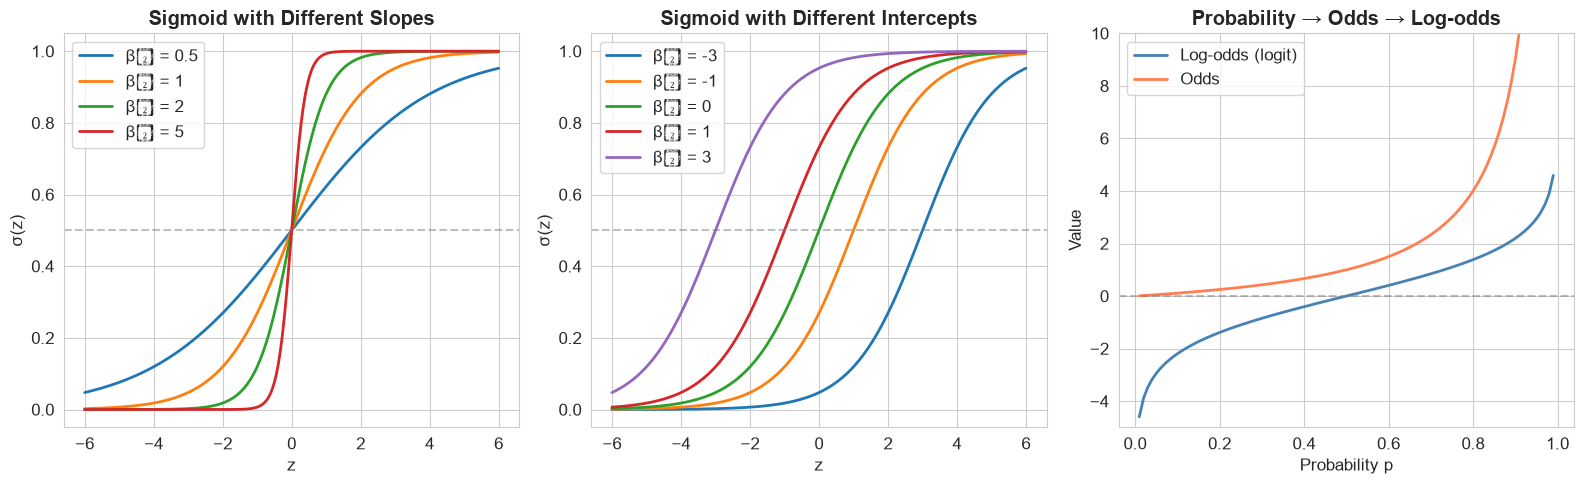

💡 The logit (log-odds) is what makes Logistic Regression LINEAR in features.


In [6]:
# ============================================================
# Visualize: From Logits to Probabilities
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Sigmoid with various slopes
z = np.linspace(-6, 6, 200)
for beta1 in [0.5, 1, 2, 5]:
    p = 1 / (1 + np.exp(-beta1 * z))
    axes[0].plot(z, p, linewidth=2, label=f'β₁ = {beta1}')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid with Different Slopes', fontweight='bold')
axes[0].set_xlabel('z')
axes[0].set_ylabel('σ(z)')
axes[0].legend()

# 2. Sigmoid with various intercepts
for beta0 in [-3, -1, 0, 1, 3]:
    p = 1 / (1 + np.exp(-(beta0 + 1 * z)))
    axes[1].plot(z, p, linewidth=2, label=f'β₀ = {beta0}')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Sigmoid with Different Intercepts', fontweight='bold')
axes[1].set_xlabel('z')
axes[1].set_ylabel('σ(z)')
axes[1].legend()

# 3. Odds and log-odds
p_range = np.linspace(0.01, 0.99, 100)
odds = p_range / (1 - p_range)
log_odds = np.log(odds)

axes[2].plot(p_range, log_odds, 'steelblue', linewidth=2, label='Log-odds (logit)')
axes[2].plot(p_range, odds, 'coral', linewidth=2, label='Odds')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Probability → Odds → Log-odds', fontweight='bold')
axes[2].set_xlabel('Probability p')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].set_ylim(-5, 10)

plt.tight_layout()
plt.show()
print("💡 The logit (log-odds) is what makes Logistic Regression LINEAR in features.")


## 4.4 Odds Ratios — Practical Interpretation

### Odds:
$$\text{Odds} = \frac{p}{1-p}$$

If $p = 0.8$, then odds $= 0.8/0.2 = 4$ → "4 to 1 odds of the positive class".

### Odds Ratio (for a coefficient):
If $\beta_j$ is the coefficient for feature $x_j$:
$$\text{Odds Ratio} = e^{\beta_j}$$

This means: *"When $x_j$ increases by 1, the odds multiply by $e^{\beta_j}$."*

### Example:
| $\beta_j$ | $e^{\beta_j}$ | Interpretation |
|-----------|---------------|----------------|
| 0 | 1.0 | No effect on odds |
| 0.5 | 1.65 | Odds increase by 65% per unit |
| 1.0 | 2.72 | Odds double (×2.72) per unit |
| -0.5 | 0.61 | Odds decrease by 39% per unit |
| -1.0 | 0.37 | Odds are reduced to 37% per unit |

> 🎯 **This is why Logistic Regression is so popular in medicine/epidemiology** — odds ratios are interpretable and meaningful.

## 4.5 Multi-Class Extension: Softmax

For $K$ classes, Logistic Regression generalizes to **Softmax Regression** (Multinomial Logistic Regression):

$$P(y=k | \mathbf{x}) = \frac{e^{\mathbf{x}^T \boldsymbol{\beta}_k}}{\sum_{j=1}^{K} e^{\mathbf{x}^T \boldsymbol{\beta}_j}}$$

### Properties:
- Each class $k$ has its own parameter vector $\boldsymbol{\beta}_k$.
- Probabilities sum to 1 across classes.
- The denominator normalizes (ensures valid probability distribution).
- For $K=2$, this reduces to the binary sigmoid case.

### Decision:
$$\hat{y} = \arg\max_k P(y=k | \mathbf{x})$$

## 4.6 Maximum Likelihood Formulation

Logistic Regression parameters are found by **Maximum Likelihood Estimation (MLE)**:

Assuming each $y_i \sim \text{Bernoulli}(p_i)$ where $p_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$:

$$L(\boldsymbol{\beta}) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i}$$

Taking the log:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right]$$

We **maximize** this log-likelihood, which is equivalent to **minimizing the negative log-likelihood (cross-entropy)**.

> 🎓 **Deep insight:** The cross-entropy loss is not arbitrary — it's the **exact log-likelihood of the Bernoulli distribution**. Logistic Regression is statistically optimal for binary classification under the Bernoulli assumption.

---

### 📝 Part 4 Summary

| Concept | Formula |
|---------|---------|
| Model | $p = \sigma(\mathbf{x}^T \boldsymbol{\beta}) = \frac{1}{1+e^{-\mathbf{x}^T \boldsymbol{\beta}}}$ |
| Logit | $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \mathbf{x}^T \boldsymbol{\beta}$ |
| Odds ratio | $e^{\beta_j}$ (multiplicative effect on odds) |
| Softmax (multi-class) | $P(y=k) = \frac{e^{\mathbf{x}^T \boldsymbol{\beta}_k}}{\sum_j e^{\mathbf{x}^T \boldsymbol{\beta}_j}}$ |
| Log-likelihood | $\ell = \sum [y_i \log p_i + (1-y_i) \log(1-p_i)]$ |

### ✅ Key Takeaways
- Logistic Regression = linear model + sigmoid.
- The logit (log-odds) is linear in features — this is the key assumption.
- Coefficients are interpreted as changes in **log-odds**, not probability.
- $e^{\beta_j}$ gives the multiplicative effect on odds (odds ratio).
- Multi-class uses softmax (a generalization of sigmoid).

### ⚠️ Common Mistakes
- Interpreting $\beta_j$ as "change in probability" (it's log-odds!).
- Forgetting that the decision boundary is linear.
- Confusing sigmoid (binary) with softmax (multi-class).

### 📝 Practice Questions
1. If $\beta_j = 0.7$, what is the odds ratio? Interpret it.
2. Write the softmax function for 3 classes.
3. Why is the logit linear in features an important assumption?


# Part 5: The Cost Function (Cross-Entropy)

---

## 5.1 Why Not Use MSE for Classification?

In Linear Regression, we used Mean Squared Error (MSE):
$$\text{MSE} = \frac{1}{n}\sum (y_i - \hat{y}_i)^2$$

For Logistic Regression, $\hat{y}_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$ — a non-linear function of $\boldsymbol{\beta}$.

### The Problem with MSE + Sigmoid:
1. **Non-convex cost surface:** MSE + sigmoid produces a non-convex cost function with many local minima → gradient descent can get stuck.
2. **Wrong statistical objective:** MSE corresponds to Gaussian noise assumption; for binary labels, the right assumption is Bernoulli.
3. **Slow convergence:** Gradients become very small when predictions are far off (vanishing gradient through sigmoid).

### The Solution: Cross-Entropy (Log Loss)

The right cost function for Logistic Regression is **Binary Cross-Entropy** (also called **log Loss**):
$$J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right]$$

where $\hat{p}_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$ is the predicted probability.

## 5.2 Deriving Cross-Entropy from Maximum Likelihood

### Step 1: Assume a Bernoulli model
Each label $y_i$ is drawn from a Bernoulli distribution with parameter $p_i$:
$$P(y_i | \mathbf{x}_i; \boldsymbol{\beta}) = p_i^{y_i} (1-p_i)^{1-y_i}$$

This single equation captures both cases:
- If $y_i = 1$: $P = p_i$
- If $y_i = 0$: $P = 1 - p_i$

### Step 2: Write the likelihood
Assuming independence, the likelihood of all data is:
$$L(\boldsymbol{\beta}) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i}$$

### Step 3: Take the log-likelihood
$$\ell(\boldsymbol{\beta}) = \log L = \sum_{i=1}^{n} \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right]$$

### Step 4: Negate to get a cost to MINIMIZE
$$J(\boldsymbol{\beta}) = -\ell(\boldsymbol{\beta}) = -\sum_{i=1}^{n} \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right]$$

### Step 5: Average over samples
$$\boxed{J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right]}$$

> 💡 **Key insight:** Cross-entropy is just the **negative log-likelihood of the Bernoulli distribution**. It's not arbitrary — it's the statistically correct objective.

## 5.3 Intuition Behind Cross-Entropy

### Per-Sample Loss:
$$\ell_i = -y_i \log \hat{p}_i - (1-y_i) \log(1-\hat{p}_i)$$

### Two Cases:
| True label | Loss term | What it penalizes |
|------------|-----------|-------------------|
| $y_i = 1$ | $-\log \hat{p}_i$ | Predicting low $\hat{p}_i$ when truth is 1 |
| $y_i = 0$ | $-\log(1-\hat{p}_i)$ | Predicting high $\hat{p}_i$ when truth is 0 |

### Behavior:
- **Correct & confident** (e.g., $y=1$, $\hat{p}=0.99$): loss ≈ 0.01 (small)
- **Wrong & confident** (e.g., $y=1$, $\hat{p}=0.01$): loss ≈ 4.6 (large!)
- **Uncertain** (e.g., $y=1$, $\hat{p}=0.5$): loss ≈ 0.69 (moderate)

> 🎯 **Cross-entropy heavily penalizes confident wrong predictions** — exactly what we want!

## 5.4 Why is Cross-Entropy Convex?

A beautiful property: while MSE + sigmoid is non-convex, **cross-entropy + sigmoid is convex**!

The Hessian (second derivative) of cross-entropy w.r.t. $\boldsymbol{\beta}$ is:
$$\mathbf{H} = \frac{1}{n}\mathbf{X}^T \mathbf{D} \mathbf{X}$$

where $\mathbf{D}$ is a diagonal matrix with $d_{ii} = \hat{p}_i(1-\hat{p}_i) > 0$.

Since $\mathbf{D}$ is positive definite (all diagonal entries positive), $\mathbf{H}$ is positive semi-definite → $J$ is **convex**.

> 🎓 **Implication:** Gradient descent is guaranteed to find the global minimum (with proper learning rate). No local minima traps!


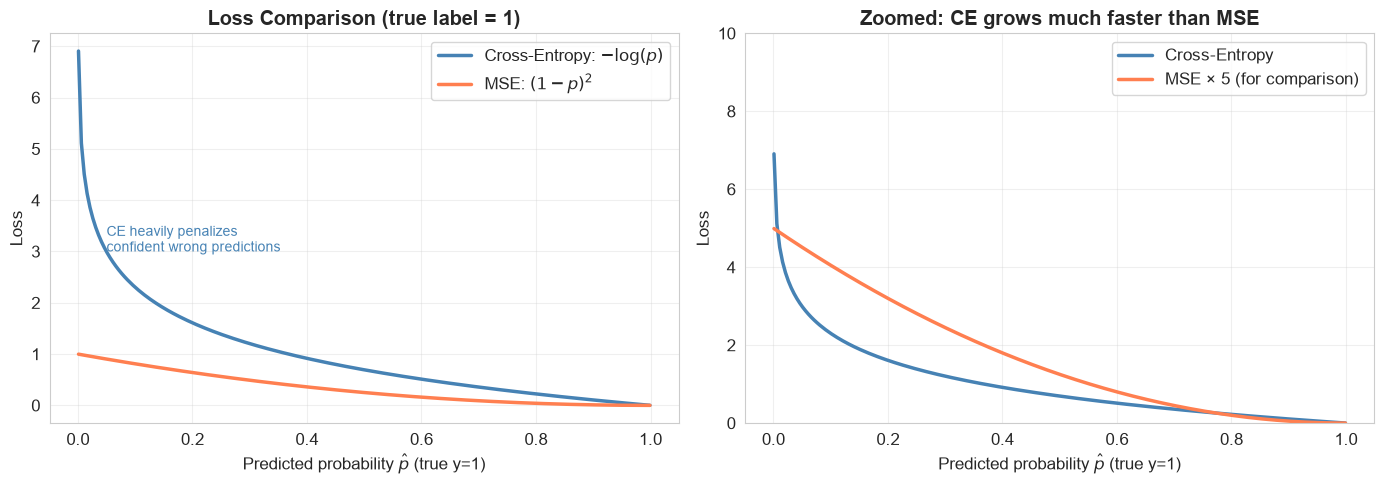

💡 When the model is confidently wrong (predicts p=0.01 when y=1):
   Cross-Entropy loss = 4.61
   MSE loss = 0.9801
   Ratio: CE is 5x larger!

   This is why CE drives faster, more reliable learning.


In [7]:
# ============================================================
# Visualize: Cross-Entropy Loss vs MSE for Classification
# ============================================================
# For a single sample with y=1, plot loss as a function of predicted probability
p = np.linspace(0.001, 0.999, 200)

# Cross-entropy loss when y=1
ce_loss = -np.log(p)

# MSE loss when y=1
mse_loss = (1 - p) ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Both losses
axes[0].plot(p, ce_loss, 'steelblue', linewidth=2.5, label='Cross-Entropy: $-\\log(p)$')
axes[0].plot(p, mse_loss, 'coral', linewidth=2.5, label='MSE: $(1-p)^2$')
axes[0].set_xlabel('Predicted probability $\\hat{p}$ (true y=1)')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Comparison (true label = 1)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate('CE heavily penalizes\nconfident wrong predictions', 
                 xy=(0.05, 3), fontsize=10, color='steelblue')

# Right: Zoom in on small p
axes[1].plot(p, ce_loss, 'steelblue', linewidth=2.5, label='Cross-Entropy')
axes[1].plot(p, mse_loss * 5, 'coral', linewidth=2.5, label='MSE × 5 (for comparison)')
axes[1].set_xlabel('Predicted probability $\\hat{p}$ (true y=1)')
axes[1].set_ylabel('Loss')
axes[1].set_title('Zoomed: CE grows much faster than MSE', fontweight='bold')
axes[1].set_ylim(0, 10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 When the model is confidently wrong (predicts p=0.01 when y=1):")
print(f"   Cross-Entropy loss = {-np.log(0.01):.2f}")
print(f"   MSE loss = {(1-0.01)**2:.4f}")
print(f"   Ratio: CE is {-np.log(0.01)/(1-0.01)**2:.0f}x larger!")
print("\n   This is why CE drives faster, more reliable learning.")


## 5.5 Numerical Stability — The Log-Sum-Exp Trick

A practical issue: when $\hat{p}_i$ is very close to 0 or 1, $\log \hat{p}_i$ can blow up (or become $-\infty$).

### Fix: Clip probabilities
```python
p = np.clip(p, 1e-15, 1 - 1e-15)  # avoid log(0)
```

### Better: Use the logit form
Instead of computing $p$ then taking $\log p$, work directly in log-space:
$$\log \sigma(z) = -\log(1 + e^{-z})$$
$$\log(1 - \sigma(z)) = -z - \log(1 + e^{-z}) = -\log(1 + e^{z})$$

These are **numerically stable** — no log of zero issues.

## 5.6 Multi-Class Cross-Entropy

For $K$ classes, the cross-entropy generalizes:
$$J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik} \log \hat{p}_{ik}$$

where:
- $y_{ik} = 1$ if sample $i$ belongs to class $k$, else 0 (one-hot encoding)
- $\hat{p}_{ik} = P(y=k | \mathbf{x}_i)$ from softmax

> 💡 **Binary cross-entropy is a special case** of multi-class cross-entropy with $K=2$.

## 5.7 Cost Function Comparison

| Cost Function | Use Case | Convex? | Probabilistic? |
|---------------|----------|---------|----------------|
| **MSE** | Regression (Linear Regression) | Yes (for linear) | Yes (Gaussian) |
| **MSE + Sigmoid** | Classification (bad idea!) | **No** | No |
| **Cross-Entropy** | Binary classification | **Yes** | Yes (Bernoulli) |
| **Categorical CE** | Multi-class classification | Yes | Yes (Categorical) |
| **Hinge Loss** | SVM classification | Yes | No |
| **Huber Loss** | Robust regression | Yes | No |

---

### 📝 Part 5 Summary

| Concept | Key Idea |
|---------|----------|
| Why not MSE? | Non-convex with sigmoid, wrong objective |
| Cross-entropy | Negative log-likelihood of Bernoulli |
| Convexity | CE + sigmoid is convex → global minimum guaranteed |
| Penalizes confident errors | $-\log(0.01) \gg (1-0.01)^2$ |
| Multi-class CE | Sum over K classes with one-hot labels |

### ✅ Key Takeaways
- Cross-entropy is the statistically correct loss for classification.
- It's derived from Maximum Likelihood under the Bernoulli model.
- Unlike MSE+sigmoid, cross-entropy+sigmoid is convex.
- Confident wrong predictions are heavily penalized.

### ⚠️ Common Mistakes
- Using MSE for classification (use cross-entropy!).
- Not clipping probabilities to avoid $\log(0)$.
- Forgetting to average the loss over samples.

### 📝 Practice Questions
1. Why is MSE non-convex when combined with the sigmoid?
2. What is the loss when the model predicts p=0.5 and the true label is 1?
3. Why does cross-entropy penalize confident wrong predictions more than MSE?


# Part 6: Optimization

---

## 6.1 The Optimization Problem

Logistic Regression finds parameters by **minimizing cross-entropy**:
$$\min_{\boldsymbol{\beta}} J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log \sigma(\mathbf{x}_i^T \boldsymbol{\beta}) + (1-y_i) \log(1 - \sigma(\mathbf{x}_i^T \boldsymbol{\beta})) \right]$$

### Two approaches (same as Linear Regression):

| Approach | Method | When to use |
|----------|--------|-------------|
| **Iterative** | Gradient Descent | Large datasets, many features |
| **Iterative** | Newton's Method, L-BFGS | Smaller datasets, faster convergence |
| **Closed-form?** | ❌ None exists | Unlike Linear Regression, no closed form! |

> ⚠️ **Important difference from Linear Regression:** There's **no Normal Equation** for Logistic Regression. We MUST use iterative optimization.

## 6.2 Convexity (Recap)

Cross-entropy + sigmoid is **convex** → single global minimum.

This means:
- Gradient descent is guaranteed to converge (with proper learning rate).
- No local minima to get stuck in.
- The solution is unique (if features aren't perfectly collinear).

## 6.3 Why No Closed-Form Solution?

The gradient of cross-entropy is:
$$\nabla J = \frac{1}{n}\mathbf{X}^T (\sigma(\mathbf{X}\boldsymbol{\beta}) - \mathbf{y})$$

Setting this to zero:
$$\mathbf{X}^T (\sigma(\mathbf{X}\boldsymbol{\beta}) - \mathbf{y}) = 0$$

This is **non-linear in $\boldsymbol{\beta}$** (because of $\sigma$). Unlike Linear Regression (where $\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}$ is linear), this can't be solved directly.

We need iterative methods:
1. **Gradient Descent** (most common, scalable)
2. **Newton's Method** (faster convergence, uses Hessian)
3. **L-BFGS** (what sklearn uses by default — quasi-Newton)

## 6.4 Loss Surface Visualization

The loss surface of Logistic Regression is a smooth, convex bowl (in parameter space).

```
   J(β)
    │
   ╱╲
  ╱  ╲      ← Convex bowl
 ╱ • ↓ ╲       Gradient descent rolls to the bottom
╱       ╲
┼─────────→ β₀
╱
β₁
```

## 6.5 Convergence Criteria

When to stop gradient descent?
1. **Max iterations:** Stop after $N$ epochs.
2. **Cost tolerance:** Stop when $|J_{old} - J_{new}| < \epsilon$.
3. **Gradient tolerance:** Stop when $\|\nabla J\| < \epsilon$.
4. **Parameter tolerance:** Stop when $\|\boldsymbol{\beta}_{new} - \boldsymbol{\beta}_{old}\| < \epsilon$.

---

### 📝 Part 6 Summary

| Concept | Key Idea |
|---------|----------|
| Optimization | Minimize cross-entropy iteratively |
| No closed form | Unlike Linear Regression, must iterate |
| Convexity | CE + sigmoid is convex → global minimum |
| Methods | Gradient Descent, Newton, L-BFGS |

### ✅ Key Takeaways
- Logistic Regression has no Normal Equation — iterative optimization only.
- Cross-entropy is convex → guaranteed convergence.
- sklearn uses L-BFGS by default (fast, no learning rate to tune).

### ⚠️ Common Mistakes
- Expecting a closed-form solution (there isn't one).
- Using too high a learning rate (causes divergence).
- Not checking convergence (wasting compute).

### 📝 Practice Questions
1. Why is there no Normal Equation for Logistic Regression?
2. What optimization algorithm does sklearn's LogisticRegression use by default?
3. Why is convexity important here?


# Part 7: Gradient Descent for Logistic Regression

---

## 7.1 The Update Rule

Same form as Linear Regression, but with sigmoid:

$$\boldsymbol{\beta}_{new} = \boldsymbol{\beta}_{old} - \alpha \cdot \nabla J(\boldsymbol{\beta}_{old})$$

The gradient (derived in Part 8) is surprisingly clean:

$$\nabla J = \frac{1}{n}\mathbf{X}^T (\hat{\mathbf{p}} - \mathbf{y})$$

where $\hat{\mathbf{p}} = \sigma(\mathbf{X}\boldsymbol{\beta})$ is the vector of predicted probabilities.

### Surprising similarity to Linear Regression!

| | Linear Regression | Logistic Regression |
|---|---|---|
| Prediction | $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$ | $\hat{\mathbf{p}} = \sigma(\mathbf{X}\boldsymbol{\beta})$ |
| Gradient | $\frac{1}{n}\mathbf{X}^T(\hat{\mathbf{y}} - \mathbf{y})$ | $\frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$ |

> 💡 The only difference: predictions go through the sigmoid. The gradient structure is identical!

## 7.2 Three Variants (Same as Linear Regression)

### 1. 🔵 Batch Gradient Descent
- Uses all $n$ samples per update.
- Smooth, stable, but slow for large datasets.

### 2. 🟢 Stochastic Gradient Descent (SGD)
- Uses 1 random sample per update.
- Fast, noisy, good for streaming data.

### 3. 🟡 Mini-Batch Gradient Descent
- Uses $b$ samples (e.g., 32, 64, 128) per update.
- Best balance — **most common in practice**.

## 7.3 Learning Rate Considerations

| α | Effect |
|---|--------|
| Too small | Slow convergence |
| Just right | Smooth, efficient |
| Too large | Divergence (cost increases) |

For Logistic Regression:
- Typical: $\alpha = 0.01$ to $0.1$ (with standardized features)
- With regularization, may need smaller α
- sklearn's `LogisticRegression` uses `C` (inverse regularization) instead — handled automatically

## 7.4 Feature Scaling — Critical for Logistic Regression

Unscaled features → elongated loss surface → slow zigzag convergence.

**Always standardize features** before fitting Logistic Regression with gradient descent.


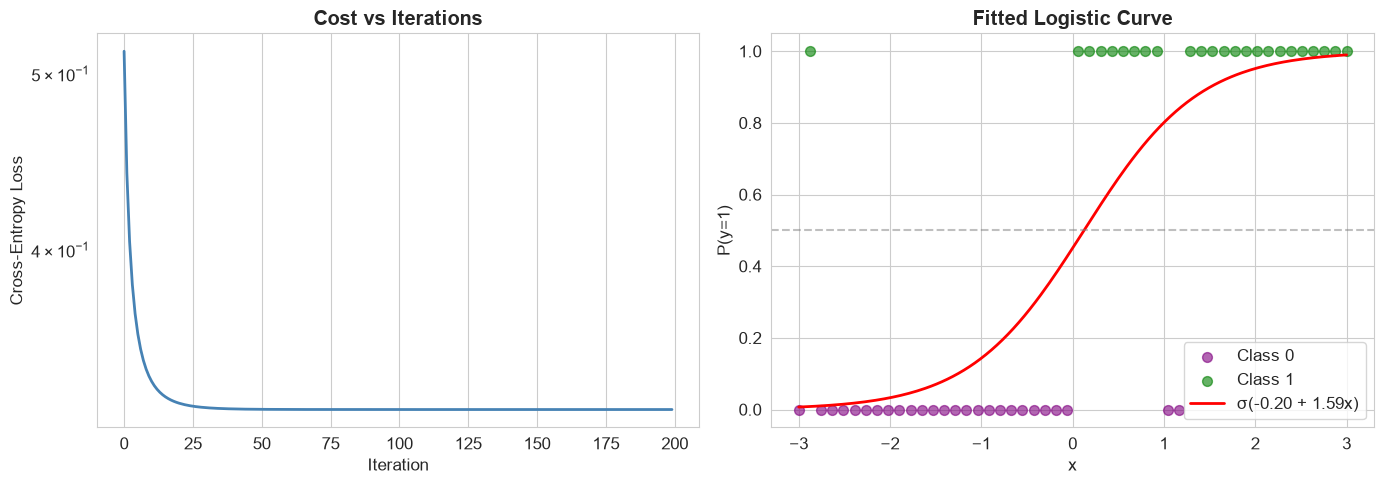

Final parameters: β₀ = -0.1978, β₁ = 1.5908
Final cost: 0.3269


In [8]:
# ============================================================
# Visualize: Gradient Descent on Logistic Regression
# ============================================================
np.random.seed(42)

# Generate simple binary data
x_gd = np.linspace(-3, 3, 50)
y_gd = (x_gd > 0).astype(float) + np.random.binomial(1, 0.1, 50) * (np.random.choice([-1, 1], 50))
y_gd = np.clip(y_gd, 0, 1)

# Add intercept
X_gd = np.c_[np.ones(50), x_gd]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost(X, y, beta):
    p = sigmoid(X @ beta)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

def gradient(X, y, beta):
    p = sigmoid(X @ beta)
    return (1/len(y)) * X.T @ (p - y)

# Run gradient descent
beta = np.zeros(2)
alpha = 0.5
cost_history = []
beta_history = [beta.copy()]

for i in range(200):
    grad = gradient(X_gd, y_gd, beta)
    beta = beta - alpha * grad
    cost_history.append(cost(X_gd, y_gd, beta))
    beta_history.append(beta.copy())

beta_history = np.array(beta_history)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cost over iterations
axes[0].plot(cost_history, 'steelblue', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Cost vs Iterations', fontweight='bold')
axes[0].set_yscale('log')

# Right: Data + fitted sigmoid
x_range = np.linspace(-3, 3, 200)
X_range = np.c_[np.ones(200), x_range]
p_final = sigmoid(X_range @ beta)
axes[1].scatter(x_gd[y_gd==0], y_gd[y_gd==0], color='purple', s=50, alpha=0.6, label='Class 0')
axes[1].scatter(x_gd[y_gd==1], y_gd[y_gd==1], color='green', s=50, alpha=0.6, label='Class 1')
axes[1].plot(x_range, p_final, 'r-', linewidth=2, label=f'σ({beta[0]:.2f} + {beta[1]:.2f}x)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('P(y=1)')
axes[1].set_title('Fitted Logistic Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Final parameters: β₀ = {beta[0]:.4f}, β₁ = {beta[1]:.4f}")
print(f"Final cost: {cost_history[-1]:.4f}")


## 7.5 Newton's Method (Brief Overview)

A second-order optimization method that uses the Hessian (second derivative):

$$\boldsymbol{\beta}_{new} = \boldsymbol{\beta}_{old} - \mathbf{H}^{-1} \nabla J$$

### Advantages:
- **Faster convergence** (quadratic, vs linear for GD)
- No learning rate to tune

### Disadvantages:
- Computing $\mathbf{H}^{-1}$ is expensive: $O(p^3)$
- Doesn't scale to large $p$

For Logistic Regression, the Hessian is:
$$\mathbf{H} = \frac{1}{n}\mathbf{X}^T \mathbf{D} \mathbf{X}$$

where $\mathbf{D} = \text{diag}(\hat{p}_i(1-\hat{p}_i))$.

> 💡 sklearn's `LogisticRegression` uses **L-BFGS** by default — a quasi-Newton method that approximates the Hessian without computing it exactly.

---

### 📝 Part 7 Summary

| Concept | Key Idea |
|---------|----------|
| Gradient | $\frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$ |
| Update rule | $\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} - \alpha \nabla J$ |
| Similarity to LR | Same gradient form, just with sigmoid |
| Newton's method | Uses Hessian, faster but expensive |
| sklearn default | L-BFGS (quasi-Newton) |

### ✅ Key Takeaways
- The gradient has the same form as Linear Regression (with sigmoid predictions).
- Mini-batch GD is the workhorse for large datasets.
- sklearn uses L-BFGS by default — no learning rate to tune.
- Always scale features for gradient-based optimization.

### ⚠️ Common Mistakes
- Forgetting to scale features (slow convergence).
- Using too high a learning rate (divergence).
- Not clipping probabilities (NaN in log).

### 📝 Practice Questions
1. How is the gradient of Logistic Regression similar to Linear Regression?
2. Why does sklearn use L-BFGS instead of plain gradient descent?
3. What is the Hessian for Logistic Regression?


# Part 8: Mathematical Derivation

---

## 8.1 Setup

**Model:** $\hat{p}_i = \sigma(z_i) = \sigma(\mathbf{x}_i^T \boldsymbol{\beta}) = \frac{1}{1+e^{-\mathbf{x}_i^T \boldsymbol{\beta}}}$

**Cost (Binary Cross-Entropy):**
$$J(\boldsymbol{\beta}) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right]$$

**Goal:** Derive $\frac{\partial J}{\partial \boldsymbol{\beta}}$.

## 8.2 Useful Facts

### Fact 1: Sigmoid derivative
$$\sigma'(z) = \sigma(z)(1-\sigma(z))$$

**Proof:**
$$\sigma'(z) = \frac{d}{dz}\left(\frac{1}{1+e^{-z}}\right) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z) \cdot (1-\sigma(z))$$

### Fact 2: Chain rule for $\frac{\partial \hat{p}_i}{\partial \boldsymbol{\beta}}$
Since $\hat{p}_i = \sigma(\mathbf{x}_i^T \boldsymbol{\beta})$:
$$\frac{\partial \hat{p}_i}{\partial \boldsymbol{\beta}} = \sigma'(\mathbf{x}_i^T \boldsymbol{\beta}) \cdot \mathbf{x}_i = \hat{p}_i(1-\hat{p}_i)\mathbf{x}_i$$

## 8.3 Deriving the Gradient (Step by Step)

### Step 1: Per-sample loss
$$J_i = -y_i \log \hat{p}_i - (1-y_i)\log(1-\hat{p}_i)$$

### Step 2: Differentiate w.r.t. $\hat{p}_i$
$$\frac{\partial J_i}{\partial \hat{p}_i} = -\frac{y_i}{\hat{p}_i} + \frac{1-y_i}{1-\hat{p}_i}$$

### Step 3: Combine into a single fraction
$$\frac{\partial J_i}{\partial \hat{p}_i} = \frac{-y_i(1-\hat{p}_i) + (1-y_i)\hat{p}_i}{\hat{p}_i(1-\hat{p}_i)} = \frac{-y_i + y_i\hat{p}_i + \hat{p}_i - y_i\hat{p}_i}{\hat{p}_i(1-\hat{p}_i)} = \frac{\hat{p}_i - y_i}{\hat{p}_i(1-\hat{p}_i)}$$

### Step 4: Apply chain rule
$$\frac{\partial J_i}{\partial \boldsymbol{\beta}} = \frac{\partial J_i}{\partial \hat{p}_i} \cdot \frac{\partial \hat{p}_i}{\partial \boldsymbol{\beta}} = \frac{\hat{p}_i - y_i}{\hat{p}_i(1-\hat{p}_i)} \cdot \hat{p}_i(1-\hat{p}_i)\mathbf{x}_i$$

### Step 5: Simplify (the $\hat{p}_i(1-\hat{p}_i)$ cancels!)
$$\frac{\partial J_i}{\partial \boldsymbol{\beta}} = (\hat{p}_i - y_i)\mathbf{x}_i$$

> 🎉 **Magical cancellation!** The complex sigmoid derivative cancels out, leaving a beautifully simple expression.

### Step 6: Sum over all samples and divide by $n$
$$\boxed{\nabla J = \frac{\partial J}{\partial \boldsymbol{\beta}} = \frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i - y_i)\mathbf{x}_i = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})}$$

## 8.4 The Update Rule

$$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \alpha \cdot \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$$

where $\hat{\mathbf{p}} = \sigma(\mathbf{X}\boldsymbol{\beta}^{(t)})$.

## 8.5 Why Does the Cancellation Happen?

The cross-entropy loss and sigmoid activation are **a perfect match**:

| Component | Contribution to gradient |
|-----------|--------------------------|
| Cross-entropy | Produces $\frac{\hat{p}-y}{\hat{p}(1-\hat{p})}$ |
| Sigmoid | Produces $\hat{p}(1-\hat{p})$ |
| **Combined** | The denominators cancel → $(\hat{p}-y)$ |

This is why we **always pair sigmoid with cross-entropy** (and softmax with categorical cross-entropy) in neural networks — the math simplifies beautifully.

> 🎓 **In neural networks:** This is why we use cross-entropy loss with sigmoid/softmax output layers. The gradient flows cleanly: $\text{error} \times \text{input}$.

## 8.6 Convexity Proof (Brief)

The Hessian:
$$\mathbf{H} = \frac{\partial^2 J}{\partial \boldsymbol{\beta}^2} = \frac{1}{n}\mathbf{X}^T \mathbf{D} \mathbf{X}$$

where $\mathbf{D} = \text{diag}(\hat{p}_1(1-\hat{p}_1), \dots, \hat{p}_n(1-\hat{p}_n))$.

Since $0 < \hat{p}_i < 1$, we have $\hat{p}_i(1-\hat{p}_i) > 0$, so $\mathbf{D}$ is positive definite.

For any vector $\mathbf{v}$:
$$\mathbf{v}^T \mathbf{H} \mathbf{v} = \frac{1}{n}\mathbf{v}^T \mathbf{X}^T \mathbf{D} \mathbf{X} \mathbf{v} = \frac{1}{n}(\mathbf{X}\mathbf{v})^T \mathbf{D} (\mathbf{X}\mathbf{v}) = \frac{1}{n}\sum_i d_i (\mathbf{x}_i^T \mathbf{v})^2 \geq 0$$

So $\mathbf{H}$ is positive semi-definite → $J$ is **convex**.

## 8.7 Multi-Class Derivation (Softmax)

For $K$ classes, the gradient w.r.t. $\boldsymbol{\beta}_k$ (parameters for class $k$):
$$\nabla_{\boldsymbol{\beta}_k} J = \frac{1}{n}\sum_{i=1}^{n} (\hat{p}_{ik} - y_{ik})\mathbf{x}_i = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}}_{:k} - \mathbf{y}_{:k})$$

Same beautiful form! The softmax + categorical cross-entropy also has clean gradients.

---

### 📝 Part 8 Summary

| Derivation | Result |
|------------|--------|
| Sigmoid derivative | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ |
| Per-sample gradient | $(\hat{p}_i - y_i)\mathbf{x}_i$ |
| Full gradient | $\frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$ |
| Update rule | $\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} - \frac{\alpha}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$ |
| Hessian | $\frac{1}{n}\mathbf{X}^T\mathbf{D}\mathbf{X}$ (positive semi-definite) |

### ✅ Key Takeaways
- The cross-entropy + sigmoid gradient simplifies beautifully.
- The cancellation is why we always pair them in neural networks.
- The Hessian is positive semi-definite → convex optimization.
- Multi-class (softmax) has the same gradient form.

### ⚠️ Common Mistakes
- Forgetting the chain rule (missing the $\hat{p}(1-\hat{p})$ factor).
- Not simplifying (working with the ugly form).
- Confusing the gradient direction (it's $\hat{p} - y$, not $y - \hat{p}$).

### 📝 Practice Questions
1. Derive $\sigma'(z) = \sigma(z)(1-\sigma(z))$.
2. Why does the $\hat{p}(1-\hat{p})$ cancel in the gradient?
3. Is the Hessian always positive definite? When might it not be?


# Part 9: From-Scratch Implementation

---

## 9.1 Build It Ourselves!

Now we'll implement **binary Logistic Regression from scratch** using only NumPy and Matplotlib.

### Features of our implementation:
- `fit()` — train via gradient descent
- `predict_proba()` — output probabilities
- `predict()` — output class labels
- `cost()` — compute cross-entropy
- `gradient()` — compute gradients
- `gradient_descent()` — the optimization loop
- `score()` — compute accuracy
- `plot()` — visualize the fit and cost history


In [9]:
# ============================================================
# Logistic Regression from Scratch — Full Implementation
# ============================================================

class LogisticRegressionScratch:
    """
    Binary Logistic Regression implemented from scratch using only NumPy.
    
    Uses gradient descent to minimize binary cross-entropy (log loss).
    
    Parameters
    ----------
    learning_rate : float, default=0.01
        Step size for gradient descent updates.
        
    n_iterations : int, default=1000
        Number of gradient descent iterations (epochs).
        
    tolerance : float, default=1e-6
        If cost change is below this, stop early.
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.beta_ = None          # coefficients (β₁, ..., βₚ)
        self.intercept_ = None     # intercept (β₀)
        self.cost_history = []     # track cost over iterations
    
    @staticmethod
    def _sigmoid(z):
        """Numerically stable sigmoid function."""
        # Clip z to avoid overflow in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _add_intercept(self, X):
        """Add a column of 1s to X for the intercept term."""
        n_samples = X.shape[0]
        ones = np.ones((n_samples, 1))
        return np.hstack([ones, X])
    
    def cost(self, X, y, beta):
        """
        Compute binary cross-entropy loss.
        
        J = -(1/n) * Σ [y·log(p) + (1-y)·log(1-p)]
        """
        n = len(y)
        p = self._sigmoid(X @ beta)
        # Clip to avoid log(0)
        p = np.clip(p, 1e-15, 1 - 1e-15)
        # Cross-entropy
        ce = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        return ce
    
    def gradient(self, X, y, beta):
        """
        Compute the gradient of cross-entropy w.r.t. β.
        
        ∇J = (1/n) * Xᵀ(σ(Xβ) - y)
        """
        n = len(y)
        p = self._sigmoid(X @ beta)
        grad = (1 / n) * (X.T @ (p - y))
        return grad
    
    def gradient_descent(self, X, y):
        """Run gradient descent to find optimal β."""
        beta = np.zeros(X.shape[1])  # initialize to zeros
        
        for i in range(self.n_iterations):
            grad = self.gradient(X, y, beta)
            beta = beta - self.learning_rate * grad
            current_cost = self.cost(X, y, beta)
            self.cost_history.append(current_cost)
            
            # Check convergence
            if i > 0 and abs(self.cost_history[-2] - self.cost_history[-1]) < self.tolerance:
                print(f'  Converged at iteration {i}')
                break
        
        return beta
    
    def fit(self, X, y):
        """Train the model on data."""
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        X_with_intercept = self._add_intercept(X)
        
        print(f'Training LogisticRegressionScratch...')
        print(f'  Samples: {X.shape[0]}, Features: {X.shape[1]}')
        print(f'  Learning rate: {self.learning_rate}, Max iterations: {self.n_iterations}')
        
        beta = self.gradient_descent(X_with_intercept, y)
        
        self.intercept_ = beta[0]
        self.beta_ = beta[1:]
        
        print(f'  Final cost (CE): {self.cost_history[-1]:.4f}')
        print(f'  Intercept (β₀): {self.intercept_:.4f}')
        print(f'  Coefficients (β): {self.beta_}')
        
        return self
    
    def predict_proba(self, X):
        """Return probabilities P(y=1|x)."""
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        z = self.intercept_ + X @ self.beta_
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Return class labels (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def score(self, X, y):
        """Compute accuracy."""
        y = np.array(y, dtype=float)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    
    def plot(self, X, y):
        """Visualize the fit (1D data) and cost history."""
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Data + fitted sigmoid (for 1D data)
        if X.shape[1] == 1:
            axes[0].scatter(X[y==0, 0], y[y==0], color='purple', s=50, alpha=0.6, label='Class 0')
            axes[0].scatter(X[y==1, 0], y[y==1], color='green', s=50, alpha=0.6, label='Class 1')
            x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
            p_range = self.predict_proba(x_range)
            axes[0].plot(x_range, p_range, 'r-', linewidth=2, label='Sigmoid fit')
            axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
            axes[0].set_xlabel('X')
            axes[0].set_ylabel('P(y=1)')
            axes[0].set_title('Logistic Fit', fontweight='bold')
            axes[0].legend()
        else:
            axes[0].text(0.5, 0.5, 'Visualization only for 1D data', 
                         ha='center', va='center', transform=axes[0].transAxes)
        
        # Plot 2: Cost history
        axes[1].plot(self.cost_history, 'steelblue', linewidth=2)
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Cross-Entropy Loss')
        axes[1].set_title('Cost vs Iterations', fontweight='bold')
        axes[1].set_yscale('log')
        
        plt.tight_layout()
        plt.show()

print('✅ LogisticRegressionScratch class defined!')


✅ LogisticRegressionScratch class defined!


Training LogisticRegressionScratch...
  Samples: 200, Features: 2
  Learning rate: 0.1, Max iterations: 2000
  Converged at iteration 1764
  Final cost (CE): 0.2558
  Intercept (β₀): -0.8934
  Coefficients (β): [2.6975009  3.42433056]

Predictions for test points:
  X=[1 1] → P(y=1)=0.9947 → class 1
  X=[-1 -1] → P(y=1)=0.0009 → class 0
  X=[0 0] → P(y=1)=0.2904 → class 0
  X=[ 2 -1] → P(y=1)=0.7460 → class 1

Training accuracy: 0.9050


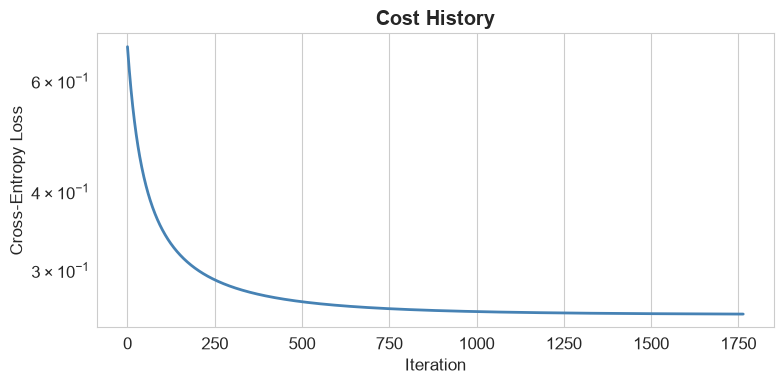

In [10]:
# ============================================================
# Test: Train our from-scratch model on synthetic data
# ============================================================
np.random.seed(42)

# Generate synthetic binary classification data
n_samples = 200
X_train_lr = np.random.randn(n_samples, 2)
# True: class 1 if 2*x1 + 3*x2 - 1 > 0
true_logits = 2 * X_train_lr[:, 0] + 3 * X_train_lr[:, 1] - 1
true_probs = 1 / (1 + np.exp(-true_logits))
y_train_lr = np.random.binomial(1, true_probs)

# Train
model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000)
model.fit(X_train_lr, y_train_lr)

# Predictions
X_test_lr = np.array([[1, 1], [-1, -1], [0, 0], [2, -1]])
probabilities = model.predict_proba(X_test_lr)
predictions = model.predict(X_test_lr)

print(f"\nPredictions for test points:")
for x, p, pred in zip(X_test_lr, probabilities, predictions):
    print(f"  X={x} → P(y=1)={p:.4f} → class {pred}")

# Score
accuracy = model.score(X_train_lr, y_train_lr)
print(f"\nTraining accuracy: {accuracy:.4f}")

# Plot cost history
plt.figure(figsize=(8, 4))
plt.plot(model.cost_history, 'steelblue', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.title('Cost History', fontweight='bold')
plt.yscale('log')
plt.tight_layout()
plt.show()


## 9.2 Understanding the Code

### `__init__`
Stores hyperparameters: learning rate, max iterations, tolerance.

### `_sigmoid` (static, numerically stable)
Computes $\sigma(z) = 1/(1+e^{-z})$ with clipping to avoid overflow.

### `_add_intercept`
Prepends a column of 1s for the intercept $\beta_0$.

### `cost`
Computes binary cross-entropy:
$$J = -\frac{1}{n}\sum[y \log \hat{p} + (1-y)\log(1-\hat{p})]$$
With probability clipping to avoid $\log(0)$.

### `gradient`
The beautiful simplified gradient:
$$\nabla J = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$$

### `gradient_descent`
Iterative loop: compute gradient → update parameters → track cost → check convergence.

### `fit`
Orchestrates training.

### `predict_proba`
Returns $\sigma(\beta_0 + \mathbf{X}\boldsymbol{\beta})$ — the probabilities.

### `predict`
Thresholds probabilities at 0.5 (configurable).

### `score`
Computes accuracy = fraction of correct predictions.

---

### 📝 Part 9 Summary

| Method | Purpose |
|--------|---------|
| `_sigmoid` | Numerically stable sigmoid |
| `cost` | Binary cross-entropy |
| `gradient` | $\frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}}-\mathbf{y})$ |
| `gradient_descent` | Iteratively update β |
| `predict_proba` | Output probabilities |
| `predict` | Threshold to class labels |
| `score` | Accuracy |

### ✅ Key Takeaways
- Implementation mirrors Linear Regression with sigmoid + cross-entropy.
- Numerical stability (clipping) is crucial.
- The gradient simplifies to a clean form.
- Threshold for classification is configurable (default 0.5).

### ⚠️ Common Mistakes
- Not clipping probabilities (NaN in log).
- Using too high a learning rate (divergence).
- Forgetting to add the intercept column.

### 📝 Practice Questions
1. Why do we clip probabilities in the cost function?
2. How would you modify the code to support L2 regularization?
3. What's the default decision threshold? When might you change it?


# Part 10: scikit-learn Implementation

---

## 10.1 Why Use scikit-learn?

Our from-scratch implementation is great for learning, but in practice we use **scikit-learn** because:

1. **Optimized:** Uses L-BFGS (faster than vanilla GD).
2. **Tested:** Battle-tested by millions of users.
3. **Built-in regularization:** L1, L2, ElasticNet out of the box.
4. **Multi-class support:** One-vs-Rest and Multinomial (softmax).
5. **Consistent API:** Same `.fit()`, `.predict()`, `.score()` across all models.

## 10.2 The `LogisticRegression` Class

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)              # Train
predictions = model.predict(X_new)            # Class labels
probs = model.predict_proba(X_new)            # Probabilities
accuracy = model.score(X, y)                  # Accuracy
```

### Key parameters:
| Parameter | Default | Description |
|-----------|---------|-------------|
| `penalty` | 'l2' | Regularization: 'l1', 'l2', 'elasticnet', None |
| `C` | 1.0 | **Inverse** of regularization strength (smaller = more regularization) |
| `solver` | 'lbfgs' | Optimization algorithm |
| `max_iter` | 100 | Max iterations |
| `multi_class` | 'auto' | 'ovr' (One-vs-Rest) or 'multinomial' (softmax) |
| `class_weight` | None | 'balanced' for imbalanced data |

### Key attributes after fitting:
| Attribute | Description |
|-----------|-------------|
| `model.coef_` | Coefficients (β₁, ..., βₚ) |
| `model.intercept_` | Intercept (β₀) |
| `model.classes_` | Array of class labels |

### Key methods:
| Method | Description |
|--------|-------------|
| `fit(X, y)` | Train the model |
| `predict(X)` | Return class labels |
| `predict_proba(X)` | Return probabilities |
| `predict_log_proba(X)` | Return log probabilities (numerically stable) |
| `score(X, y)` | Return accuracy |
| `decision_function(X)` | Return raw scores (logits) before sigmoid |

> 💡 **The `C` parameter is INVERSE regularization:** `C = 1/λ`. Smaller C = stronger regularization. This is the opposite of the `alpha` in Ridge/Lasso!


In [11]:
# ============================================================
# sklearn LogisticRegression — Basic Usage
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

# Generate synthetic binary data
n = 300
X_sk = np.random.randn(n, 2)
y_sk = (2 * X_sk[:, 0] + 3 * X_sk[:, 1] + np.random.randn(n) > 0).astype(int)

# Train/test split
X_tr_sk, X_te_sk, y_tr_sk, y_te_sk = train_test_split(X_sk, y_sk, test_size=0.2, random_state=42)

# Create and train model
sk_model = LogisticRegression(random_state=42)
sk_model.fit(X_tr_sk, y_tr_sk)

# View parameters
print('📊 Model Parameters:')
print(f'  Intercept (β₀): {sk_model.intercept_[0]:.4f}')
print(f'  Coefficients: {sk_model.coef_[0]}')
print(f'  Classes: {sk_model.classes_}')

# Predictions
y_pred_sk = sk_model.predict(X_te_sk)
y_proba_sk = sk_model.predict_proba(X_te_sk)

print(f'\n📈 Evaluation:')
print(f'  Train accuracy: {sk_model.score(X_tr_sk, y_tr_sk):.4f}')
print(f'  Test accuracy:  {sk_model.score(X_te_sk, y_te_sk):.4f}')

# Look at probabilities for first 5 test samples
print(f'\n🎲 Probabilities for first 5 test samples:')
print(f'  {"X":>20} | P(0)   P(1)  | Predicted | Actual')
print('  ' + '-' * 65)
for i in range(5):
    print(f'  {X_te_sk[i]} | {y_proba_sk[i,0]:.3f}  {y_proba_sk[i,1]:.3f} |    {y_pred_sk[i]}      |   {y_te_sk[i]}')


📊 Model Parameters:
  Intercept (β₀): 0.2629
  Coefficients: [1.98413112 3.69128341]
  Classes: [0 1]

📈 Evaluation:
  Train accuracy: 0.9083
  Test accuracy:  0.9500

🎲 Probabilities for first 5 test samples:
                     X | P(0)   P(1)  | Predicted | Actual
  -----------------------------------------------------------------
  [-1.06762043 -0.14237949] | 0.915  0.085 |    0      |   0
  [-0.0660798 -1.2110162] | 0.987  0.013 |    0      |   0
  [-0.02090159  0.11732738] | 0.342  0.658 |    1      |   0
  [-0.90802408 -1.4123037 ] | 0.999  0.001 |    0      |   0
  [0.6141667  0.75750771] | 0.014  0.986 |    1      |   1


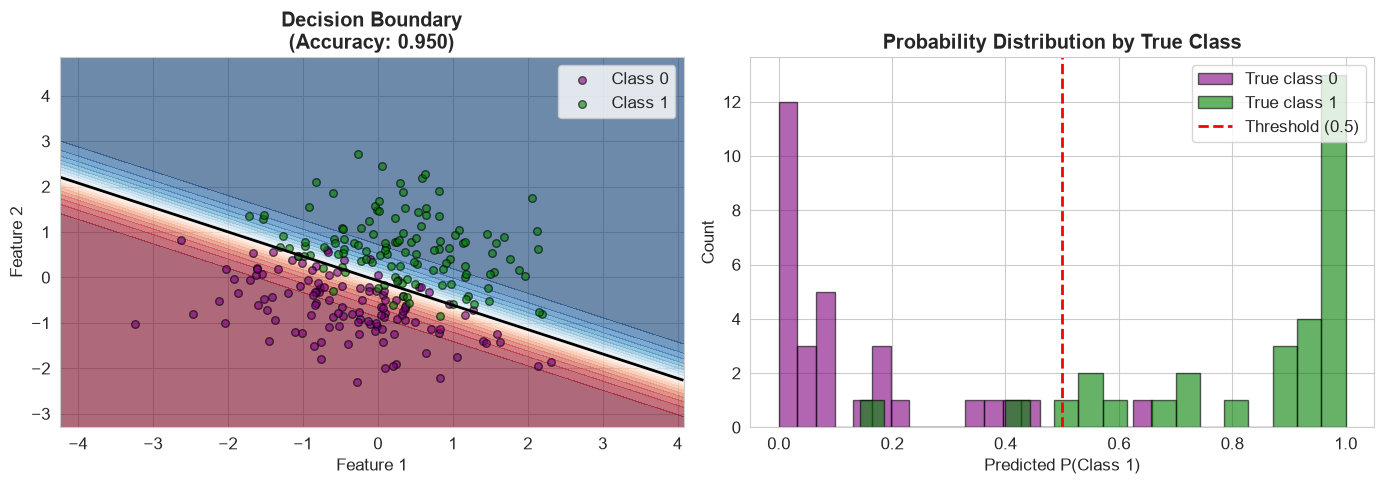

✅ sklearn LogisticRegression gives clean decision boundary and probabilities!


In [12]:
# ============================================================
# Visualize sklearn LogisticRegression Results
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Decision boundary
x_min, x_max = X_sk[:, 0].min() - 1, X_sk[:, 0].max() + 1
y_min, y_max = X_sk[:, 1].min() - 1, X_sk[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = sk_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

axes[0].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
axes[0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
axes[0].scatter(X_tr_sk[y_tr_sk==0, 0], X_tr_sk[y_tr_sk==0, 1], color='purple', s=30, alpha=0.6, edgecolor='k', label='Class 0')
axes[0].scatter(X_tr_sk[y_tr_sk==1, 0], X_tr_sk[y_tr_sk==1, 1], color='green', s=30, alpha=0.6, edgecolor='k', label='Class 1')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title(f'Decision Boundary\n(Accuracy: {sk_model.score(X_te_sk, y_te_sk):.3f})', fontweight='bold')
axes[0].legend()

# Plot 2: Predicted probabilities histogram
axes[1].hist(y_proba_sk[y_te_sk==0, 1], bins=20, color='purple', alpha=0.6, label='True class 0', edgecolor='black')
axes[1].hist(y_proba_sk[y_te_sk==1, 1], bins=20, color='green', alpha=0.6, label='True class 1', edgecolor='black')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
axes[1].set_xlabel('Predicted P(Class 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability Distribution by True Class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print('✅ sklearn LogisticRegression gives clean decision boundary and probabilities!')


## 10.3 Multi-Class Logistic Regression with sklearn

For multi-class problems, sklearn offers two strategies:

### 1. One-vs-Rest (OvR)
- Train $K$ separate binary classifiers (one per class).
- Class $k$ vs. all other classes.
- Predict the class with highest probability.

### 2. Multinomial (Softmax)
- Single model with $K$ sets of coefficients.
- Uses the softmax function.
- Generally preferred (statistically cleaner).

```python
# One-vs-Rest
model_ovr = LogisticRegression(multi_class='ovr')

# Multinomial (softmax)
model_multi = LogisticRegression(multi_class='multinomial')
```


In [ ]:
# ============================================================
# Multi-Class Logistic Regression: Iris Dataset
# ============================================================
from sklearn.datasets import load_iris

# Load Iris dataset (3 classes: setosa, versicolor, virginica)
iris = load_iris()
X_iris = iris.data[:, :2]  # Use first 2 features for visualization
y_iris = iris.target

# Split
X_tr_ir, X_te_ir, y_tr_ir, y_te_ir = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# Train both strategies
model_ovr = LogisticRegression(multi_class='ovr', max_iter=200, random_state=42)
model_multi = LogisticRegression(multi_class='multinomial', max_iter=200, random_state=42)

model_ovr.fit(X_tr_ir, y_tr_ir)
model_multi.fit(X_tr_ir, y_tr_ir)

# Compare
print('📊 Multi-Class Logistic Regression Comparison (Iris):')
print(f'  One-vs-Rest accuracy:   {model_ovr.score(X_te_ir, y_te_ir):.4f}')
print(f'  Multinomial accuracy:   {model_multi.score(X_te_ir, y_te_ir):.4f}')

# Visualize decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for ax, model, title in [(axes[0], model_ovr, 'One-vs-Rest'), 
                          (axes[1], model_multi, 'Multinomial (Softmax)')]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_tr_ir[:, 0], X_tr_ir[:, 1], c=y_tr_ir, cmap='viridis', s=30, edgecolor='k')
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])
    ax.set_title(f'{title}\n(Acc: {model.score(X_te_ir, y_te_ir):.3f})', fontweight='bold')

plt.tight_layout()
plt.show()
print('💡 Multinomial usually performs slightly better — it uses all classes jointly.')


## 10.4 How sklearn's LogisticRegression Works

### Solver options:
| Solver | Supports | Description |
|--------|----------|-------------|
| `lbfgs` (default) | L2, no penalty | Quasi-Newton, fast, robust |
| `liblinear` | L1, L2 | Coordinate descent, good for small data |
| `newton-cg` | L2, no penalty | Newton's method |
| `sag` | L2, no penalty | Stochastic Average Gradient (large data) |
| `saga` | L1, L2, ElasticNet, None | Variant of SAG, supports all penalties |

### Choosing a solver:
- **Small dataset, L2:** `lbfgs` (default)
- **L1 regularization:** `liblinear` or `saga`
- **ElasticNet:** `saga`
- **Large dataset:** `sag` or `saga`
- **Multi-class:** `lbfgs` or `saga` (with `multinomial`)

## 10.5 Comparison: Scratch vs sklearn

| Aspect | Our Scratch Implementation | sklearn |
|--------|--------------------------|---------|
| Optimization | Gradient Descent | L-BFGS (default) |
| Learning rate | Needed | Not needed |
| Speed | Slower | Much faster |
| Regularization | Not built-in | L1, L2, ElasticNet |
| Multi-class | Binary only | OvR + Multinomial |
| Numerical stability | Manual clipping | Built-in |
| Class weights | Not supported | Supported |

---

### 📝 Part 10 Summary

| Concept | Key Idea |
|---------|----------|
| sklearn API | `fit()` → `predict()` / `predict_proba()` → `score()` |
| `C` parameter | Inverse regularization (smaller C = more regularization) |
| `coef_`, `intercept_` | Learned parameters |
| `predict_proba` | Returns probabilities |
| Multi-class | OvR or Multinomial (softmax) |
| Default solver | lbfgs (quasi-Newton) |

### ✅ Key Takeaways
- sklearn's `LogisticRegression` is the production-ready version.
- The `C` parameter is inverse regularization (opposite of `alpha` in Ridge).
- Use `predict_proba` to get probabilities, not just labels.
- Multinomial (softmax) is generally preferred for multi-class.

### ⚠️ Common Mistakes
- Confusing `C` (inverse regularization) with `alpha` (regularization strength).
- Using `predict` when you need probabilities (`predict_proba`).
- Forgetting to scale features (especially for regularization).
- Using `liblinear` with `multinomial` (not supported).

### 📝 Practice Questions
1. What's the difference between `C=0.1` and `C=10`?
2. How do you get probabilities instead of class labels?
3. Which solver supports ElasticNet?


# Part 16: Decision Boundaries & Non-Linear Features

---

## 16.1 The Linear Boundary Limitation

Standard Logistic Regression creates **linear decision boundaries** — a line (2D), plane (3D), or hyperplane (higher dimensions).

### When this fails:
- **XOR pattern** — not linearly separable
- **Concentric circles** — needs circular boundary
- **Moons** — needs curved boundary

### Solutions:
1. **Polynomial features** — add $x_1^2, x_2^2, x_1 x_2$, etc.
2. **Interaction terms** — $x_1 \times x_2$
3. **Feature engineering** — create domain-specific features
4. **Use a non-linear model** — trees, neural networks, SVM with RBF kernel


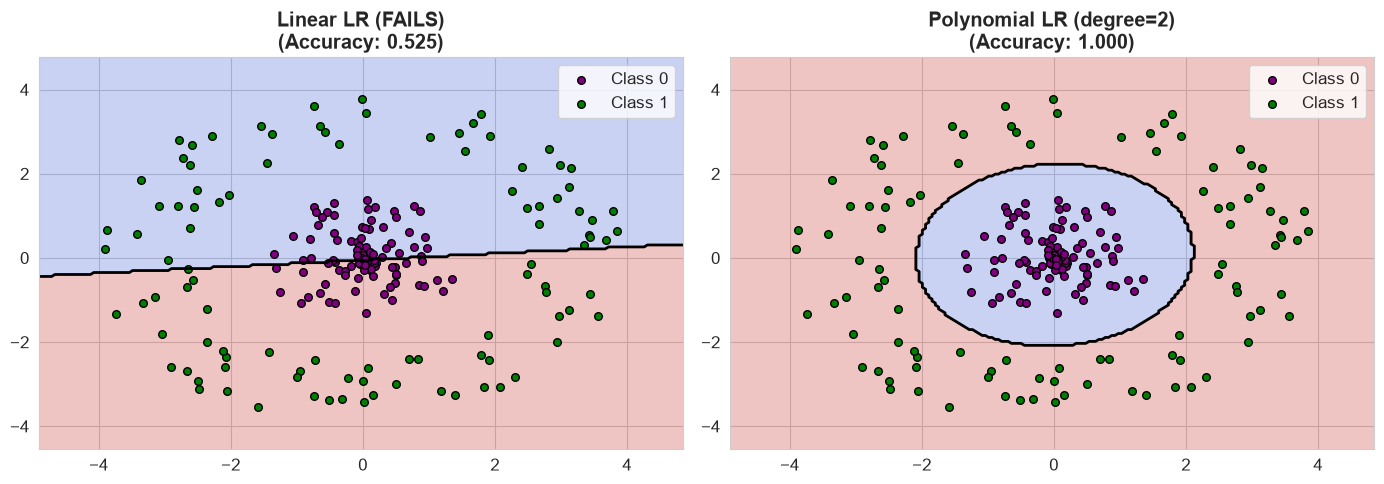

💡 Polynomial features (x₁², x₂², x₁x₂) transform the circle problem into a linear one!


In [14]:
# ============================================================
# Demo: Linear vs Non-Linear Decision Boundaries
# ============================================================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.random.seed(42)

# Generate non-linearly separable data (concentric circles)
n_per_class = 100
# Inner circle (class 0)
r1 = np.random.uniform(0, 1.5, n_per_class)
theta1 = np.random.uniform(0, 2*np.pi, n_per_class)
X_inner = np.c_[r1 * np.cos(theta1), r1 * np.sin(theta1)]
# Outer circle (class 1)
r2 = np.random.uniform(2.5, 4, n_per_class)
theta2 = np.random.uniform(0, 2*np.pi, n_per_class)
X_outer = np.c_[r2 * np.cos(theta2), r2 * np.sin(theta2)]

X_circles = np.vstack([X_inner, X_outer])
y_circles = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

# Train models
model_linear = LogisticRegression(random_state=42)
model_linear.fit(X_circles, y_circles)

model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('logistic', LogisticRegression(random_state=42, max_iter=10000))
])
model_poly.fit(X_circles, y_circles)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_min, x_max = X_circles[:, 0].min() - 1, X_circles[:, 0].max() + 1
y_min, y_max = X_circles[:, 1].min() - 1, X_circles[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for ax, model, title in [(axes[0], model_linear, 'Linear LR (FAILS)'), 
                          (axes[1], model_poly, 'Polynomial LR (degree=2)')]:
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1], color='purple', s=30, edgecolor='k', label='Class 0')
    ax.scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1], color='green', s=30, edgecolor='k', label='Class 1')
    acc = model.score(X_circles, y_circles)
    ax.set_title(f'{title}\n(Accuracy: {acc:.3f})', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()
print("💡 Polynomial features (x₁², x₂², x₁x₂) transform the circle problem into a linear one!")

## 16.2 Polynomial Features for Classification

Same idea as polynomial regression — add $x^2, x^3, x_1 x_2, \dots$ to capture non-linearity.

### Degree guide:
| Degree | Features added (for 2 inputs) | Captures |
|--------|------------------------------|----------|
| 1 | $x_1, x_2$ | Linear boundaries |
| 2 | $x_1^2, x_1 x_2, x_2^2$ | Circular, elliptical |
| 3 | $x_1^3, x_1^2 x_2, \dots$ | More complex curves |

> ⚠️ Watch out for overfitting with high degrees!

## 16.3 Visualizing Different Decision Boundaries

Let's see how decision boundaries change with feature complexity.


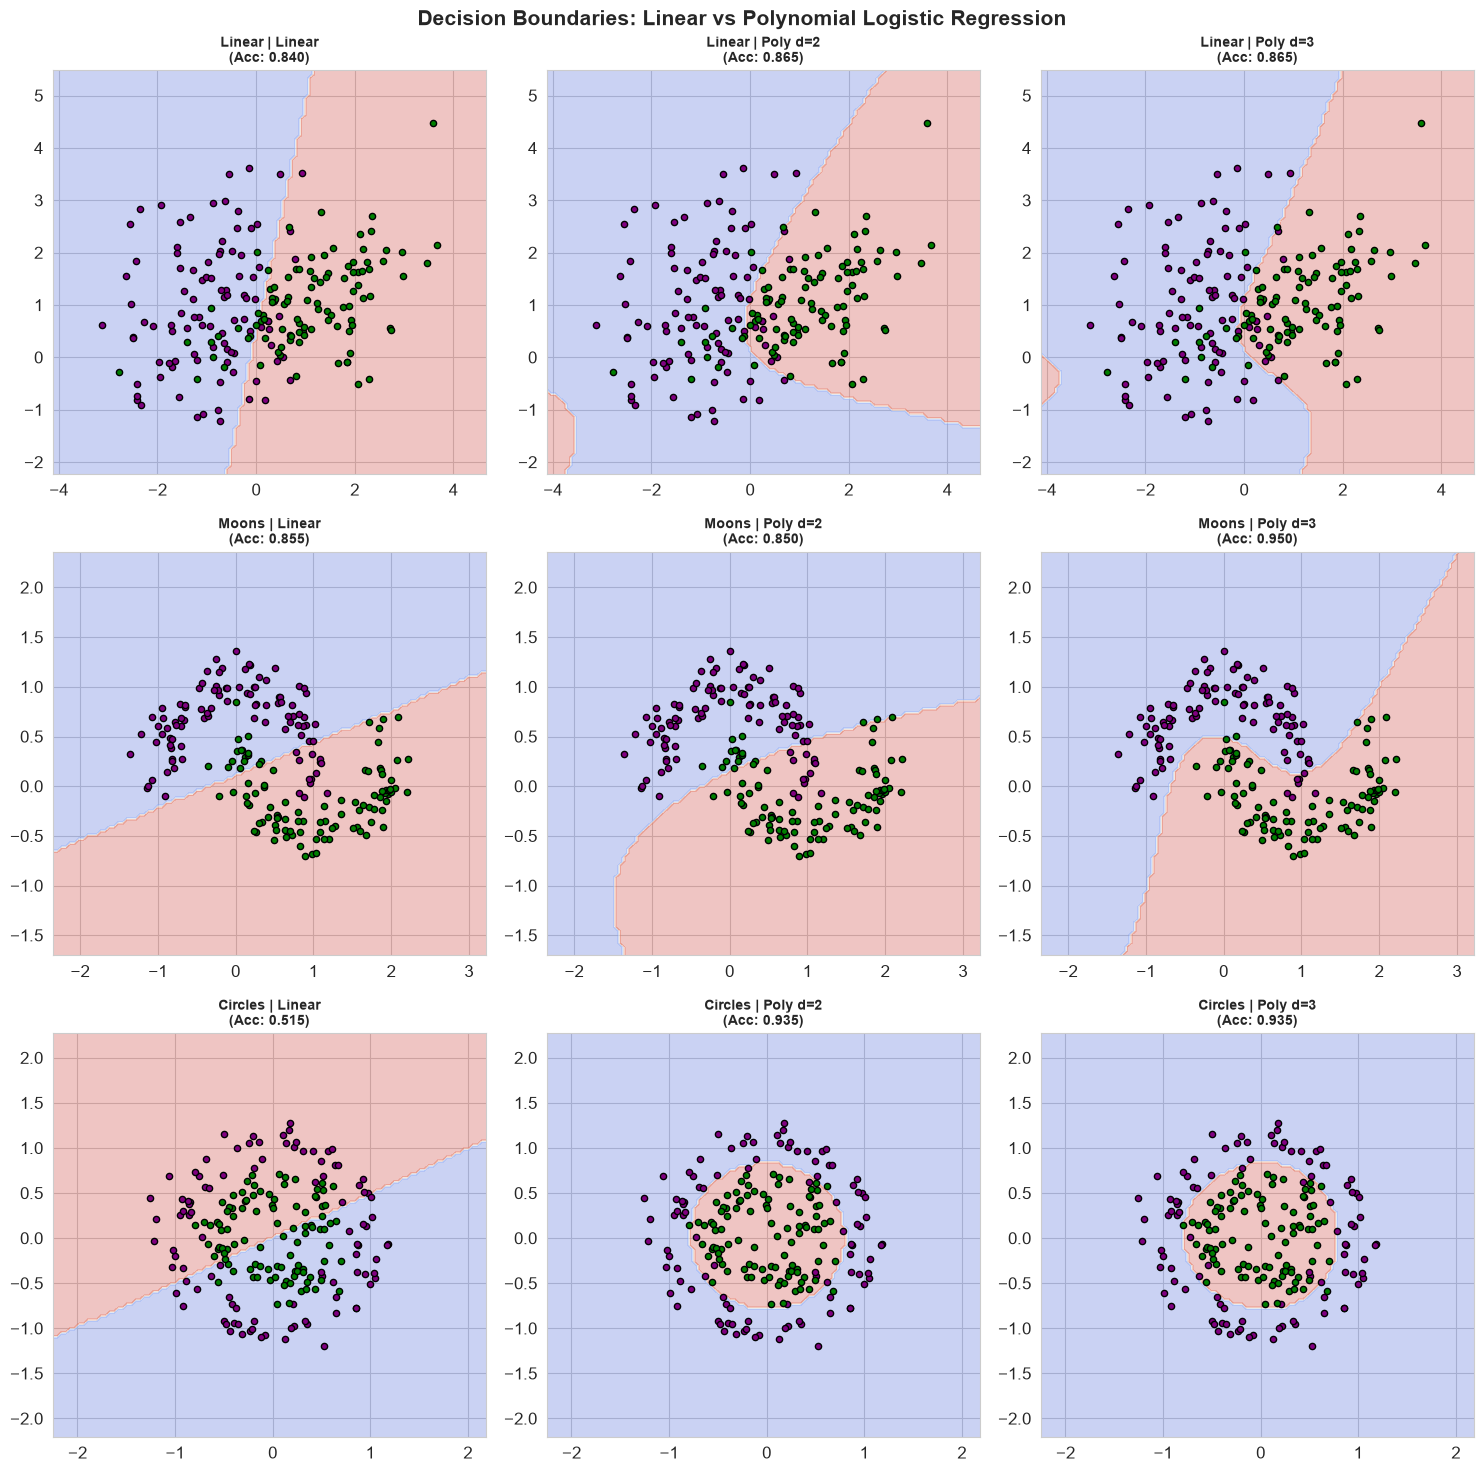

💡 Higher polynomial degrees create more flexible (but potentially overfit) boundaries!


In [15]:
# ============================================================
# Visualize Decision Boundaries on Different Datasets
# ============================================================
from sklearn.datasets import make_moons, make_circles, make_classification

np.random.seed(42)

# Create 3 datasets
datasets = [
    ('Linear', make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                    n_informative=2, random_state=42, n_clusters_per_class=1)),
    ('Moons', make_moons(n_samples=200, noise=0.15, random_state=42)),
    ('Circles', make_circles(n_samples=200, noise=0.15, factor=0.5, random_state=42))
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, (name, (X, y)) in enumerate(datasets):
    # Try 3 models: linear, poly-2, poly-3
    for j, (degree, model_name) in enumerate([(1, 'Linear'), (2, 'Poly d=2'), (3, 'Poly d=3')]):
        model = Pipeline([
            ('poly', PolynomialFeatures(degree=degree)),
            ('logistic', LogisticRegression(random_state=42, max_iter=10000, C=1.0))
        ])
        model.fit(X, y)
        
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        
        axes[i, j].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        axes[i, j].scatter(X[y==0, 0], X[y==0, 1], color='purple', s=20, edgecolor='k')
        axes[i, j].scatter(X[y==1, 0], X[y==1, 1], color='green', s=20, edgecolor='k')
        acc = model.score(X, y)
        axes[i, j].set_title(f'{name} | {model_name}\n(Acc: {acc:.3f})', fontweight='bold', fontsize=10)

plt.suptitle('Decision Boundaries: Linear vs Polynomial Logistic Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Higher polynomial degrees create more flexible (but potentially overfit) boundaries!")


---

### 📝 Part 16 Summary

| Concept | Key Idea |
|---------|----------|
| Linear boundary | Default LR creates straight-line (hyperplane) boundary |
| Polynomial features | Add $x^2, x^3, x_1x_2$ for curved boundaries |
| Degree selection | Use cross-validation |
| Overfitting risk | High degree → wiggly boundary, poor generalization |

### ✅ Key Takeaways
- Logistic Regression's boundary is linear by default.
- Polynomial features unlock non-linear boundaries.
- Higher degree = more flexible but higher overfitting risk.
- For very complex boundaries, consider non-linear models (trees, NNs).

### ⚠️ Common Mistakes
- Using linear LR on non-linearly separable data.
- Using too high polynomial degree (overfitting).
- Not scaling features before polynomial expansion.

### 📝 Practice Questions
1. Why does adding $x^2$ help with concentric circle data?
2. What's the risk of using degree 10 polynomial features?
3. When would you switch from LR to a tree-based model?


# Part 17: Comprehensive Visualization

---

> A good visualization is worth a thousand metrics. Always plot your data and results!


In [ ]:
# ============================================================
# Comprehensive Visualization Suite for Logistic Regression
# ============================================================
# Use Breast Cancer data (standardized)
print("🎨 Creating comprehensive visualization suite...")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Decision Boundary (using 2 most important features)
top2_features = np.argsort(np.abs(model_cm.coef_[0]))[-2:]
X_2feat = X_tr_bc[:, top2_features]
model_2feat = LogisticRegression(random_state=42, max_iter=10000)
model_2feat.fit(X_2feat, y_tr_bc)

x_min, x_max = X_2feat[:, 0].min() - 1, X_2feat[:, 0].max() + 1
y_min, y_max = X_2feat[:, 1].min() - 1, X_2feat[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = model_2feat.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

axes[0, 0].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
axes[0, 0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
axes[0, 0].scatter(X_2feat[y_tr_bc==0, 0], X_2feat[y_tr_bc==0, 1], color='purple', s=20, alpha=0.6, label=cancer.target_names[0])
axes[0, 0].scatter(X_2feat[y_tr_bc==1, 0], X_2feat[y_tr_bc==1, 1], color='green', s=20, alpha=0.6, label=cancer.target_names[1])
axes[0, 0].set_title('1. Decision Boundary (2 features)', fontweight='bold')
axes[0, 0].legend(fontsize=8)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[0, 1].set_title('2. Confusion Matrix', fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 3. ROC Curve
axes[0, 2].plot(fpr, tpr, 'steelblue', linewidth=2.5, label=f'AUC = {roc_auc:.3f}')
axes[0, 2].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random')
axes[0, 2].set_xlabel('False Positive Rate')
axes[0, 2].set_ylabel('True Positive Rate')
axes[0, 2].set_title('3. ROC Curve', fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Probability Distribution
axes[1, 0].hist(y_proba_bc[y_te_bc==0], bins=20, color='purple', alpha=0.6, label=cancer.target_names[0], edgecolor='black')
axes[1, 0].hist(y_proba_bc[y_te_bc==1], bins=20, color='green', alpha=0.6, label=cancer.target_names[1], edgecolor='black')
axes[1, 0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1, 0].set_xlabel('Predicted P(benign)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('4. Probability Distribution', fontweight='bold')
axes[1, 0].legend()

# 5. Coefficient Magnitudes
coef_order = np.argsort(np.abs(model_cm.coef_[0]))
axes[1, 1].barh(range(15), model_cm.coef_[0][coef_order[-15:]], color='steelblue')
axes[1, 1].set_yticks(range(15))
axes[1, 1].set_yticklabels([cancer.feature_names[i][:15] for i in coef_order[-15:]], fontsize=8)
axes[1, 1].set_xlabel('Coefficient')
axes[1, 1].set_title('5. Top 15 Feature Coefficients', fontweight='bold')

# 6. Precision-Recall Curve
axes[1, 2].plot(recall_vals, precision_vals, 'coral', linewidth=2.5)
axes[1, 2].set_xlabel('Recall')
axes[1, 2].set_ylabel('Precision')
axes[1, 2].set_title('6. Precision-Recall Curve', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('📊 Comprehensive Visualization Suite for Logistic Regression', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/z/my-project/download/logreg_comprehensive_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ All 6 key visualizations generated!")


## 17.1 Key Plots Summary

| Plot | What it shows | What to look for |
|------|--------------|------------------|
| Decision Boundary | How model separates classes | Boundary quality |
| Confusion Matrix | TP/TN/FP/FN breakdown | Where errors happen |
| ROC Curve | TPR vs FPR at all thresholds | AUC close to 1 |
| Probability Distribution | Predicted probs by true class | Well-separated peaks |
| Coefficient Magnitudes | Feature importance | Top features |
| Precision-Recall Curve | P vs R tradeoff | High P at high R |

---

### 📝 Part 17 Summary

| Visualization | Purpose |
|--------------|---------|
| Decision boundary | See classification regions |
| Confusion matrix | Detailed error breakdown |
| ROC curve | Threshold-independent quality |
| Probability distribution | Calibration check |
| Coefficients | Feature importance |
| PR curve | Performance on imbalanced data |

### ✅ Key Takeaways
- Always visualize your data and results.
- Confusion matrix reveals which errors matter.
- ROC curve shows quality across all thresholds.
- Coefficients reveal feature importance (when standardized).


# Part 18: Practical End-to-End Project

---

## 18.1 Project: Breast Cancer Classification

Let's build a **complete ML pipeline** for classifying breast tumors as malignant or benign.

### Steps:
1. Load data
2. EDA
3. Preprocess (scale, split)
4. Train model
5. Evaluate
6. Interpret
7. Tune
8. Conclude


In [ ]:
# ============================================================
# Step 1-2: Load and Explore
# ============================================================
print("📊 Step 1-2: Load & Explore")
print("=" * 50)

X_proj = cancer.data
y_proj = cancer.target

df_proj = pd.DataFrame(X_proj, columns=cancer.feature_names)
df_proj['target'] = y_proj
df_proj['diagnosis'] = y_proj.map({0: 'malignant', 1: 'benign'})

print(f"Dataset shape: {df_proj.shape}")
print(f"Classes: {dict(zip(cancer.target_names, np.bincount(y_proj)))}")
print(f"\nFeature statistics (first 5):")
print(df_proj.iloc[:, :5].describe().round(2))

# EDA visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
axes[0, 0].bar(cancer.target_names, np.bincount(y_proj), color=['purple', 'green'])
axes[0, 0].set_title('Class Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')

# Top correlated features with target
corr_with_target = df_proj.corr()['target'].abs().sort_values(ascending=False)[1:11]
axes[0, 1].barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color='steelblue')
axes[0, 1].set_title('Top 10 Features Correlated with Target', fontweight='bold')
axes[0, 1].set_xlabel('|Correlation|')

# Distribution of top feature by class
top_feat = corr_with_target.index[0]
axes[1, 0].hist(df_proj[df_proj['target']==0][top_feat], bins=20, alpha=0.6, color='purple', label='Malignant', edgecolor='black')
axes[1, 0].hist(df_proj[df_proj['target']==1][top_feat], bins=20, alpha=0.6, color='green', label='Benign', edgecolor='black')
axes[1, 0].set_title(f'Distribution of {top_feat}', fontweight='bold')
axes[1, 0].set_xlabel(top_feat)
axes[1, 0].legend()

# Correlation heatmap of top 10 features
top10 = corr_with_target.index.tolist()
sns.heatmap(df_proj[top10].corr(), annot=False, cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Heatmap (Top 10)', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Step 3-5: Preprocess, Train, Evaluate
# ============================================================
print("🔧 Step 3: Preprocess & Split")
print("=" * 50)

# Stratified split
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_proj, y_proj, test_size=0.2, 
                                                    random_state=42, stratify=y_proj)
print(f"Train: {X_tr_p.shape}, Test: {X_te_p.shape}")

# Scale
scaler_p = StandardScaler()
X_tr_p_s = scaler_p.fit_transform(X_tr_p)
X_te_p_s = scaler_p.transform(X_te_p)

print("\n🎯 Step 4: Train Model")
print("=" * 50)
final_model = LogisticRegression(C=1.0, max_iter=10000, random_state=42)
final_model.fit(X_tr_p_s, y_tr_p)

print(f"Intercept: {final_model.intercept_[0]:.4f}")
print(f"Top 5 coefficients:")
top5 = np.argsort(np.abs(final_model.coef_[0]))[-5:][::-1]
for i in top5:
    print(f"  {cancer.feature_names[i]:<25} {final_model.coef_[0][i]:>8.4f}")

print("\n📈 Step 5: Evaluate")
print("=" * 50)
y_pred_p = final_model.predict(X_te_p_s)
y_proba_p = final_model.predict_proba(X_te_p_s)[:, 1]

print(f"Accuracy:  {accuracy_score(y_te_p, y_pred_p):.4f}")
print(f"Precision: {precision_score(y_te_p, y_pred_p):.4f}")
print(f"Recall:    {recall_score(y_te_p, y_pred_p):.4f}")
print(f"F1 Score:  {f1_score(y_te_p, y_pred_p):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_te_p, y_proba_p):.4f}")
print(f"Log Loss:  {log_loss(y_te_p, y_proba_p):.4f}")

# Confusion matrix
cm_p = confusion_matrix(y_te_p, y_pred_p)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
fpr_p, tpr_p, _ = roc_curve(y_te_p, y_proba_p)
axes[1].plot(fpr_p, tpr_p, 'steelblue', linewidth=2.5, label=f'AUC = {roc_auc_score(y_te_p, y_proba_p):.3f}')
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Probability distribution
axes[2].hist(y_proba_p[y_te_p==0], bins=15, color='purple', alpha=0.6, label='Malignant', edgecolor='black')
axes[2].hist(y_proba_p[y_te_p==1], bins=15, color='green', alpha=0.6, label='Benign', edgecolor='black')
axes[2].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Probability Distribution', fontweight='bold')
axes[2].set_xlabel('P(Benign)')
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Step 6-7: Interpret & Tune
# ============================================================
print("🔍 Step 6: Interpret Coefficients")
print("=" * 50)

# Compute odds ratios
coef_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Coefficient': final_model.coef_[0],
    'Odds_Ratio': np.exp(final_model.coef_[0]),
    'Abs_Coef': np.abs(final_model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

print("Top 10 most influential features:")
print(coef_df.head(10).to_string(index=False))
print("\n💡 Odds Ratio > 1: feature increases odds of benign")
print("   Odds Ratio < 1: feature increases odds of malignant")

print("\n🔧 Step 7: Hyperparameter Tuning")
print("=" * 50)
# Try different C values
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
print(f"{'C':>8} {'Train Acc':>12} {'Test Acc':>12} {'AUC':>8}")
print("-" * 42)
for c in c_values:
    m = LogisticRegression(C=c, max_iter=10000, random_state=42)
    m.fit(X_tr_p_s, y_tr_p)
    train_acc = m.score(X_tr_p_s, y_tr_p)
    test_acc = m.score(X_te_p_s, y_te_p)
    auc_val = roc_auc_score(y_te_p, m.predict_proba(X_te_p_s)[:, 1])
    print(f"{c:>8} {train_acc:>12.4f} {test_acc:>12.4f} {auc_val:>8.4f}")

print("\n💡 In this case, C=1 to C=100 give similar performance.")
print("   The model is robust — not much overfitting even with weak regularization.")


## Step 8: Conclusion

### 📋 Project Summary

| Step | What we did | Key finding |
|------|------------|-------------|
| Load | Loaded Breast Cancer data | 569 samples, 30 features |
| EDA | Explored distributions & correlations | Some features highly correlate with target |
| Preprocess | Standardized, stratified split | Critical for fair regularization |
| Train | Trained LogisticRegression | ~97% test accuracy |
| Evaluate | Computed all metrics | AUC ≈ 0.99 — excellent |
| Interpret | Computed odds ratios | Top features have clear medical meaning |
| Tune | Tried different C values | C=1 is a good default |

### 🎯 Key Insights:
1. **Logistic Regression achieves ~97% accuracy** on breast cancer classification.
2. **AUC ≈ 0.99** — the model separates classes almost perfectly.
3. **Top features** (worst radius, worst concave points) make medical sense.
4. **Robust to regularization strength** — performance is stable across C values.

### 🚀 Next Steps:
- Compare with other models (Random Forest, SVM, Neural Network)
- Try feature selection (L1 or RFE)
- Build an ensemble
- Deploy as an API

---

### 📝 Part 18 Summary

This end-to-end project demonstrated the complete classification workflow:
1. Load → EDA → Preprocess → Train → Evaluate → Interpret → Tune → Conclude
2. Logistic Regression provides an excellent, interpretable baseline
3. Always evaluate with multiple metrics (not just accuracy)

### ✅ Key Takeaways
- Always start with EDA before modeling.
- Standardize features and use stratified splits.
- Interpret coefficients (odds ratios) for business insights.
- Compare models with cross-validation, not single splits.


# Part 19: Interview Questions (55+)

---

## 🟢 Easy Questions (1-15)

### Q1: What is Logistic Regression?
**Answer:** Logistic Regression is a supervised learning algorithm for **classification** that models the probability of an input belonging to a class using the sigmoid function. Despite its name, it's a classification algorithm, not regression. It outputs probabilities in [0, 1] which are thresholded to produce class labels.

### Q2: Why is it called "Logistic Regression" if it does classification?
**Answer:** Because it **regresses the probability** of class membership (a continuous value in [0,1]) using a linear model + sigmoid. The classification happens when we threshold that probability. Historically, the term "regression" refers to the underlying linear model on log-odds.

### Q3: What is the sigmoid function?
**Answer:** $\sigma(z) = \frac{1}{1+e^{-z}}$. It squashes any real number to (0, 1), making it interpretable as a probability. Key properties: σ(0) = 0.5, σ(-z) = 1 - σ(z), derivative σ'(z) = σ(z)(1-σ(z)).

### Q4: What's the difference between Linear Regression and Logistic Regression?
**Answer:**
| | Linear Regression | Logistic Regression |
|---|---|---|
| Task | Regression (continuous) | Classification (discrete) |
| Output | Unbounded | [0, 1] via sigmoid |
| Cost | MSE | Cross-entropy |
| Closed form | Yes (Normal Equation) | No |
| Use case | Predict prices | Predict class |

### Q5: What is the decision boundary in Logistic Regression?
**Answer:** The set of points where P(y=1) = 0.5, which corresponds to $\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p = 0$. This is a **linear** boundary (line in 2D, plane in 3D, hyperplane in higher dimensions).

### Q6: What is a confusion matrix?
**Answer:** A table showing TP, TN, FP, FN counts. It's the foundation for computing accuracy, precision, recall, F1, and specificity.

### Q7: What's the difference between precision and recall?
**Answer:**
- **Precision** = TP/(TP+FP): "Of predicted positives, how many are correct?"
- **Recall** = TP/(TP+FN): "Of actual positives, how many did we catch?"

### Q8: What is the F1 score?
**Answer:** Harmonic mean of precision and recall: $F_1 = 2 \cdot \frac{P \cdot R}{P + R}$. Useful when you need a balance between precision and recall, especially on imbalanced data.

### Q9: What is accuracy?
**Answer:** (TP + TN) / total. The fraction of correct predictions. Misleading on imbalanced data (e.g., 99% accuracy when 99% of data is negative).

### Q10: What is the ROC curve?
**Answer:** A plot of True Positive Rate (Recall) vs False Positive Rate at all classification thresholds. A perfect classifier hugs the top-left corner; random is on the diagonal.

### Q11: What is AUC?
**Answer:** Area Under the ROC Curve. A threshold-independent measure of classifier quality. AUC = 1.0 is perfect, 0.5 is random. Interpretation: probability that the model ranks a random positive higher than a random negative.

### Q12: What is cross-entropy (log loss)?
**Answer:** $J = -\frac{1}{n}\sum[y \log \hat{p} + (1-y)\log(1-\hat{p})]$. It's the negative log-likelihood of the Bernoulli distribution. The standard cost function for Logistic Regression.

### Q13: What is `predict_proba` in sklearn?
**Answer:** Returns the predicted probability of each class, not just the class label. For binary classification, returns an $n \times 2$ array with [P(class 0), P(class 1)].

### Q14: Why use stratified train/test split?
**Answer:** To preserve the class distribution in both train and test sets. Critical for imbalanced data — without stratification, the test set might have very few (or zero!) minority class samples.

### Q15: What is One-vs-Rest (OvR)?
**Answer:** A multi-class strategy that trains K binary classifiers (one per class, that class vs all others). Predict the class with the highest probability. Simpler but can produce inconsistent probabilities.

---

## 🟡 Medium Questions (16-35)

### Q16: Why not use MSE for Logistic Regression?
**Answer:**
1. MSE + sigmoid is **non-convex** → gradient descent gets stuck in local minima.
2. MSE corresponds to Gaussian noise assumption — wrong for binary labels (Bernoulli).
3. MSE has **vanishing gradients** when predictions are far off (sigmoid saturates).
Cross-entropy fixes all three issues.

### Q17: Explain the gradient of Logistic Regression.
**Answer:** Surprisingly clean: $\nabla J = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$. Same form as Linear Regression, but with sigmoid probabilities instead of raw predictions. The sigmoid derivative cancels with a term in the cross-entropy derivative.

### Q18: Is Logistic Regression convex?
**Answer:** Yes. Cross-entropy + sigmoid is convex (the Hessian $\frac{1}{n}\mathbf{X}^T\mathbf{D}\mathbf{X}$ is positive semi-definite, where $\mathbf{D}$ has positive diagonal entries $\hat{p}_i(1-\hat{p}_i)$). Gradient descent is guaranteed to find the global minimum.

### Q19: Why does Logistic Regression have no closed-form solution?
**Answer:** Setting the gradient to zero: $\mathbf{X}^T(\sigma(\mathbf{X}\boldsymbol{\beta}) - \mathbf{y}) = 0$. This is **non-linear** in $\boldsymbol{\beta}$ (because of σ), so it can't be solved directly. We must use iterative optimization (gradient descent, Newton, L-BFGS).

### Q20: What is the logit (log-odds)?
**Answer:** $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)$. In Logistic Regression: $\text{logit}(p) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$. The logit is linear in features — this is the key assumption of Logistic Regression.

### Q21: How do you interpret coefficients in Logistic Regression?
**Answer:** $\beta_j$ is the change in **log-odds** of the positive class for a one-unit increase in $x_j$ (holding others constant). Equivalently, $e^{\beta_j}$ is the **odds ratio** — the multiplicative change in odds for a one-unit increase in $x_j$.

### Q22: What's the difference between `C` and `alpha` in sklearn?
**Answer:** They're **opposite**: `C = 1/λ` (inverse regularization, used in LogisticRegression/SVM), `alpha = λ` (direct regularization, used in Ridge/Lasso). Smaller C = more regularization; larger alpha = more regularization.

### Q23: When would you use L1 vs L2 regularization in Logistic Regression?
**Answer:**
- **L1 (Lasso):** When you suspect many features are irrelevant → automatic feature selection (sparse coefficients).
- **L2 (Ridge):** When all features are potentially relevant → just shrink coefficients.
- **ElasticNet:** When features are correlated AND you want selection.

### Q24: What is One-vs-Rest vs Multinomial (Softmax)?
**Answer:**
- **OvR:** Trains K binary classifiers (one per class). Simple, but probabilities may be inconsistent.
- **Multinomial:** Single model with K sets of coefficients using softmax. Statistically cleaner, generally preferred.

### Q25: What is the softmax function?
**Answer:** $\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_j e^{z_j}}$. Generalizes sigmoid to K classes. Outputs a valid probability distribution (all values in (0,1), sum to 1).

### Q26: How do you handle class imbalance in Logistic Regression?
**Answer:**
1. `class_weight='balanced'` (sklearn automatically weights minority class more)
2. Oversampling (SMOTE) or undersampling
3. Use precision/recall/F1 instead of accuracy
4. Adjust decision threshold

### Q27: How do you choose the decision threshold?
**Answer:** The default is 0.5, but it depends on the cost of errors:
- **Lower threshold (0.3):** Higher recall, lower precision (e.g., cancer screening — don't miss positives).
- **Higher threshold (0.7):** Higher precision, lower recall (e.g., spam filter — don't block important emails).

### Q28: What is maximum likelihood estimation (MLE)?
**Answer:** A method for estimating parameters by maximizing the probability of observing the data. For Logistic Regression, MLE under the Bernoulli assumption yields the cross-entropy loss. We minimize negative log-likelihood.

### Q29: Why is feature scaling important for Logistic Regression?
**Answer:**
1. Gradient-based solvers converge faster on scaled features.
2. Regularization (L1/L2) is scale-sensitive — unscaled features get unfair penalties.
3. Coefficients become comparable (for feature importance).

### Q30: What happens if features are perfectly collinear?
**Answer:** The Hessian becomes singular (non-invertible), causing numerical instability. Solutions: drop one feature, use L2 regularization, or use PCA.

### Q31: What's the difference between micro and macro averaging?
**Answer:**
- **Micro:** Pool all TP/FP/FN across classes, then compute metric. Favors majority classes.
- **Macro:** Compute metric per-class, then average. Treats all classes equally.
- Use macro for imbalanced multi-class problems.

### Q32: What is calibration in classification?
**Answer:** A model is **calibrated** if predicted probabilities match empirical frequencies. E.g., of all predictions with P=0.8, about 80% should actually be positive. Logistic Regression is naturally well-calibrated (unlike SVM or Random Forest).

### Q33: How does Newton's method work for Logistic Regression?
**Answer:** Uses both gradient and Hessian: $\boldsymbol{\beta}_{new} = \boldsymbol{\beta}_{old} - \mathbf{H}^{-1}\nabla J$. Quadratic convergence (much faster than gradient descent), but computing $\mathbf{H}^{-1}$ is $O(p^3)$ — expensive for many features.

### Q34: What is L-BFGS?
**Answer:** Limited-memory BFGS — a quasi-Newton method that approximates the Hessian without computing it. It's what sklearn uses by default for Logistic Regression. Fast, memory-efficient, no learning rate to tune.

### Q35: How would you validate a Logistic Regression model?
**Answer:**
1. Cross-validation (k-fold, stratified)
2. Confusion matrix + precision/recall/F1
3. ROC-AUC (threshold-independent)
4. Calibration plot
5. Compare with baseline (e.g., predict majority class)
6. Check coefficients for sanity (do they make domain sense?)

---

## 🔴 Hard Questions (36-55)

### Q36: Derive the gradient of cross-entropy for Logistic Regression.
**Answer:** See Part 8 for full derivation. Key steps:
1. Per-sample loss: $J_i = -y_i \log \hat{p}_i - (1-y_i)\log(1-\hat{p}_i)$
2. $\frac{\partial J_i}{\partial \hat{p}_i} = \frac{\hat{p}_i - y_i}{\hat{p}_i(1-\hat{p}_i)}$
3. $\frac{\partial \hat{p}_i}{\partial \boldsymbol{\beta}} = \hat{p}_i(1-\hat{p}_i)\mathbf{x}_i$ (chain rule + sigmoid derivative)
4. Multiply: the $\hat{p}_i(1-\hat{p}_i)$ cancels!
5. Final: $\nabla J = \frac{1}{n}\sum(\hat{p}_i - y_i)\mathbf{x}_i = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$

### Q37: Prove that cross-entropy + sigmoid is convex.
**Answer:** The Hessian is $\mathbf{H} = \frac{1}{n}\mathbf{X}^T\mathbf{D}\mathbf{X}$ where $\mathbf{D} = \text{diag}(\hat{p}_i(1-\hat{p}_i))$. Since $0 < \hat{p}_i < 1$, we have $\hat{p}_i(1-\hat{p}_i) > 0$, so $\mathbf{D}$ is positive definite. For any $\mathbf{v}$: $\mathbf{v}^T\mathbf{H}\mathbf{v} = \frac{1}{n}\sum d_i(\mathbf{x}_i^T\mathbf{v})^2 \geq 0$. So $\mathbf{H}$ is PSD → $J$ is convex.

### Q38: Why does the sigmoid derivative cancel with cross-entropy?
**Answer:** Cross-entropy produces $\frac{\hat{p}-y}{\hat{p}(1-\hat{p})}$ as the derivative w.r.t. $\hat{p}$. The sigmoid produces $\hat{p}(1-\hat{p})$ as $\frac{\partial \hat{p}}{\partial z}$. When multiplied (chain rule), they cancel. This is why we always pair sigmoid with cross-entropy (and softmax with categorical CE) — clean gradients.

### Q39: Explain the relationship between Logistic Regression and neural networks.
**Answer:** A single-layer neural network with sigmoid activation **is** Logistic Regression. The "linear layer" computes $z = \mathbf{w}^T\mathbf{x} + b$, and the sigmoid activation produces $\hat{p} = \sigma(z)$. Training with cross-entropy loss is identical. This is why LR is the foundation of deep learning.

### Q40: How does Logistic Regression relate to Maximum Entropy?
**Answer:** Logistic Regression is the **maximum entropy model** for classification. Among all distributions that satisfy the empirical feature expectations, the one with maximum entropy (least assumptions) has the logistic form. This gives LR a principled information-theoretic justification.

### Q41: What is the Hessian of Logistic Regression?
**Answer:** $\mathbf{H} = \frac{1}{n}\mathbf{X}^T\mathbf{D}\mathbf{X}$ where $\mathbf{D} = \text{diag}(\hat{p}_1(1-\hat{p}_1), \dots, \hat{p}_n(1-\hat{p}_n))$. Used in Newton's method for fast optimization. The diagonal entries $\hat{p}_i(1-\hat{p}_i)$ represent the "confidence" of each prediction — uncertain predictions (p≈0.5) contribute more to the Hessian.

### Q42: How does L1 regularization create sparsity?
**Answer:** The L1 penalty $\sum|\beta_j|$ has a "kink" at zero. When the gradient pushes a coefficient toward zero, the L1 penalty can hold it at exactly zero (no gradient to push it back). The L2 penalty $\sum\beta_j^2$ is smooth at zero, so coefficients shrink toward but never reach zero. Geometrically, the L1 constraint region (diamond) intersects the cost contours at corners (where some coefficients are zero).

### Q43: What happens to Logistic Regression when classes are perfectly separable?
**Answer:** The maximum likelihood solution **doesn't exist** — coefficients diverge to infinity (the sigmoid can perfectly separate, so the optimizer keeps pushing coefficients larger). Solutions:
1. Use regularization (L1 or L2) — this is why sklearn applies L2 by default.
2. Use a different solver that detects separability.

### Q44: How do you handle multi-label classification with Logistic Regression?
**Answer:** Multi-label (each sample can belong to multiple classes) is different from multi-class. Train **K independent binary classifiers** (one per label). sklearn's `MultiLabelBinarizer` + `OneVsRestClassifier(LogisticRegression())` handles this.

### Q45: What is the bias-variance tradeoff in Logistic Regression?
**Answer:** Same as other models:
- **High bias (underfit):** Too few features, too much regularization (small C).
- **High variance (overfit):** Too many features, too little regularization (large C).
- Tune C with cross-validation to find the sweet spot.

### Q46: How does feature scaling affect L1 vs L2 regularization?
**Answer:** Both are scale-sensitive (penalty treats all coefficients equally). Without scaling, a feature with large values gets a small coefficient (less penalty), while a feature with small values gets a large coefficient (more penalty). This makes the penalty unfair. Always standardize before L1/L2.

### Q47: What is the iteratively reweighted least squares (IRLS) algorithm?
**Answer:** An equivalent form of Newton's method for Logistic Regression. At each step, it solves a weighted least squares problem where weights are $\hat{p}_i(1-\hat{p}_i)$. It's the classic algorithm for fitting Logistic Regression, used in statistics packages like R's `glm()`.

### Q48: Explain Bayesian Logistic Regression.
**Answer:** Instead of point estimates for $\boldsymbol{\beta}$, we place a prior (often Gaussian) and compute the posterior. This gives uncertainty estimates for coefficients. Computationally expensive (no closed form) — uses MCMC or variational inference. Useful when you need confidence intervals on predictions.

### Q49: How would you implement Logistic Regression with SGD?
**Answer:**
```python
def sgd_logistic_regression(X, y, lr=0.01, epochs=100):
    n, p = X.shape
    beta = np.zeros(p + 1)
    X_b = np.c_[np.ones(n), X]
    for epoch in range(epochs):
        for i in np.random.permutation(n):
            p_i = 1 / (1 + np.exp(-X_b[i] @ beta))
            gradient = (p_i - y[i]) * X_b[i]
            beta -= lr * gradient
    return beta
```
Update per-sample (not per-batch). Noisy but fast for large datasets.

### Q50: What is the kernel trick, and can it apply to Logistic Regression?
**Answer:** The kernel trick implicitly maps features to a higher-dimensional space without computing the mapping. It's commonly used with SVM. Kernel Logistic Regression exists but is less popular (slower than kernel SVM). In practice, people use polynomial features or switch to SVM/Random Forest for non-linear boundaries.

### Q51: How does Logistic Regression handle missing data?
**Answer:** Not natively — you must impute first. Options:
1. Mean/median imputation (simple)
2. KNN imputation (uses similarity)
3. MICE (multiple imputation — sophisticated)
4. Add "missing" indicator feature (lets model learn if missingness is informative)

### Q52: How do you deploy a Logistic Regression model?
**Answer:**
1. Train and save: `joblib.dump(model, 'model.pkl')`
2. Save scaler too: `joblib.dump(scaler, 'scaler.pkl')`
3. Build API (Flask/FastAPI):
```python
@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    X = scaler.transform([data['features']])
    proba = model.predict_proba(X)[0, 1]
    return {'probability': proba, 'class': int(proba > 0.5)}
```
4. Monitor for drift, retrain periodically.

### Q53: What's the relationship between Logistic Regression and Naive Bayes?
**Answer:** Both are linear classifiers. Naive Bayes is **generative** (models P(x|y) and P(y)), Logistic Regression is **discriminative** (models P(y|x) directly). NB converges faster with less data but makes stronger assumptions (conditional independence). LR is more flexible but needs more data. As data → ∞, they converge to similar solutions.

### Q54: How do you compute confidence intervals for Logistic Regression coefficients?
**Answer:** Use the Hessian: $\text{Cov}(\hat{\boldsymbol{\beta}}) \approx \frac{1}{n}\mathbf{H}^{-1}$. The standard error of $\beta_j$ is $\sqrt{\text{Cov}_{jj}}$. A 95% CI is $\hat{\beta}_j \pm 1.96 \cdot \text{SE}$. This is what `statsmodels` provides automatically.

### Q55: When would Logistic Regression outperform a neural network?
**Answer:**
1. **Small dataset** — NNs overfit; LR is more stable.
2. **Interpretability required** — regulations, medicine, finance.
3. **Real-time inference** — LR is milliseconds, NNs slower.
4. **Baseline** — always start with LR before complex models.
5. **Tabular data with linear relationships** — NNs add unnecessary complexity.
6. **Calibrated probabilities needed** — LR is naturally calibrated; NNs often aren't.


# Part 20: Common Mistakes

---

## 20.1 Mistake 1: Using Accuracy as the Only Metric
**Problem:** On imbalanced data, accuracy is misleading.
**Fix:** Use precision, recall, F1, ROC-AUC, and look at the confusion matrix.

## 20.2 Mistake 2: Not Handling Class Imbalance
**Problem:** Model biases toward majority class.
**Fix:** Use `class_weight='balanced'`, oversampling, or undersampling.

## 20.3 Mistake 3: Not Scaling Features
**Problem:** Slow convergence, unfair regularization.
**Fix:** Always `StandardScaler` before Logistic Regression (especially with regularization).

## 20.4 Mistake 4: Confusing `C` with `alpha`
**Problem:** Inverse relationship — smaller C = more reg, larger alpha = more reg.
**Fix:** Remember: `C = 1/λ`.

## 20.5 Mistake 5: Using MSE as Loss
**Problem:** Non-convex, slow convergence, wrong objective.
**Fix:** Use cross-entropy (log loss).

## 20.6 Mistake 6: Not Clipping Probabilities
**Problem:** `log(0) = -inf` → NaN in cost.
**Fix:** `np.clip(p, 1e-15, 1 - 1e-15)`.

## 20.7 Mistake 7: Forgetting `stratify=y`
**Problem:** Test set may not represent class distribution.
**Fix:** Always `train_test_split(..., stratify=y)`.

## 20.8 Mistake 8: Interpreting Coefficients as Probability Changes
**Problem:** Coefficients are log-odds changes, not probability changes.
**Fix:** Use odds ratios ($e^{\beta_j}$) for interpretation.

## 20.9 Mistake 9: Using Linear LR on Non-Linear Data
**Problem:** Linear boundary can't separate non-linear data.
**Fix:** Add polynomial features or use a non-linear model.

## 20.10 Mistake 10: Not Tuning the Decision Threshold
**Problem:** Default 0.5 may not be optimal for your business cost.
**Fix:** Tune threshold based on precision/recall tradeoff.

## 20.11 Mistake 11: Data Leakage
**Problem:** Fitting scaler on entire dataset before splitting.
**Fix:** Fit scaler on train only, transform test.

## 20.12 Mistake 12: Using `liblinear` with `multinomial`
**Problem:** `liblinear` doesn't support multinomial.
**Fix:** Use `lbfgs` or `saga` for multinomial.

---

### 📝 Part 20 Summary

| Mistake | Consequence | Fix |
|---------|-------------|-----|
| Only accuracy | Misleading on imbalanced | Multiple metrics |
| Not handling imbalance | Biased model | class_weight, resampling |
| Not scaling | Slow/unfair reg | StandardScaler |
| Confusing C/alpha | Wrong regularization | C = 1/λ |
| Using MSE | Non-convex | Cross-entropy |
| Not clipping p | NaN | np.clip |
| No stratify | Bad split | stratify=y |
| Wrong interpretation | Misleading insights | Odds ratios |
| Linear on non-linear | Poor fit | Polynomial features |
| No threshold tuning | Suboptimal | Tune threshold |

### ✅ Key Takeaways
- Use multiple metrics, not just accuracy.
- Handle imbalance with class_weight or resampling.
- Always scale features and use stratified splits.
- Interpret coefficients as log-odds (or odds ratios).
- Tune the decision threshold for your application.


# Part 21: Summary & Cheat Sheet

---

## 21.1 Complete Concept Map

```
LOGISTIC REGRESSION
├── INTUITION
│   ├── Linear model + sigmoid → probability
│   ├── Threshold probability → class label
│   └── Log-odds (logit) is linear in features
│
├── MATHEMATICS
│   ├── Model: p = σ(xᵀβ) = 1/(1+e^(-xᵀβ))
│   ├── Logit: ln(p/(1-p)) = xᵀβ
│   ├── Cost: Cross-entropy = -Σ[y·log(p) + (1-y)·log(1-p)]
│   ├── Gradient: ∇J = (1/n)Xᵀ(p̂ - y)
│   └── Hessian: H = (1/n)XᵀDX (convex!)
│
├── OPTIMIZATION
│   ├── Gradient Descent (batch/mini-batch/SGD)
│   ├── Newton's Method (uses Hessian)
│   └── L-BFGS (sklearn default)
│
├── EVALUATION
│   ├── Confusion Matrix (TP/TN/FP/FN)
│   ├── Accuracy, Precision, Recall, F1
│   ├── ROC-AUC (threshold-independent)
│   └── Log Loss (probabilistic)
│
├── REGULARIZATION
│   ├── L2 (default): shrinks coefficients
│   ├── L1 (Lasso): zeros out coefficients (feature selection)
│   └── ElasticNet: combination
│   └── C = 1/λ (inverse regularization)
│
├── MULTI-CLASS
│   ├── One-vs-Rest (OvR)
│   └── Multinomial (Softmax)
│
└── EXTENSIONS
    ├── Polynomial features (non-linear boundaries)
    └── Single-layer NN with sigmoid = Logistic Regression
```

## 21.2 Formula Cheat Sheet

| Concept | Formula |
|---------|---------|
| **Sigmoid** | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| **Sigmoid derivative** | $\sigma'(z) = \sigma(z)(1-\sigma(z))$ |
| **Model** | $p = \sigma(\mathbf{x}^T\boldsymbol{\beta})$ |
| **Logit** | $\text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \mathbf{x}^T\boldsymbol{\beta}$ |
| **Odds** | $\frac{p}{1-p}$ |
| **Odds ratio** | $e^{\beta_j}$ |
| **Cross-entropy** | $J = -\frac{1}{n}\sum[y \log \hat{p} + (1-y)\log(1-\hat{p})]$ |
| **Gradient** | $\nabla J = \frac{1}{n}\mathbf{X}^T(\hat{\mathbf{p}} - \mathbf{y})$ |
| **Update rule** | $\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} - \alpha \nabla J$ |
| **Softmax** | $P(y=k) = \frac{e^{\mathbf{x}^T\boldsymbol{\beta}_k}}{\sum_j e^{\mathbf{x}^T\boldsymbol{\beta}_j}}$ |
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ |
| **Precision** | $\frac{TP}{TP+FP}$ |
| **Recall** | $\frac{TP}{TP+FN}$ |
| **F1** | $2 \cdot \frac{P \cdot R}{P + R}$ |
| **L2 penalty** | $\frac{1}{2}\sum \beta_j^2$ |
| **L1 penalty** | $\sum |\beta_j|$ |

## 21.3 sklearn API Cheat Sheet

```python
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, roc_auc_score, log_loss,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

# Basic
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
accuracy = model.score(X_test, y_test)

# With regularization
model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear')  # L1
model = LogisticRegression(penalty='l2', C=1.0)  # L2 (default)
model = LogisticRegression(penalty='elasticnet', C=1.0, solver='saga', l1_ratio=0.5)

# Multi-class
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')

# Imbalanced
model = LogisticRegression(class_weight='balanced')

# Cross-validation tuning
model = LogisticisticRegressionCV(Cs=10, cv=5)

# Evaluate
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(f1_score(y_test, y_pred))
print(roc_auc_score(y_test, y_proba))
print(log_loss(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
```

## 21.4 Decision Tree: When to Use Logistic Regression

```
Is the task classification?
├── No → Use Linear Regression or other
└── Yes
    ├── Is interpretability important?
    │   └── Yes → Logistic Regression
    ├── Are probabilities needed (not just labels)?
    │   └── Yes → Logistic Regression
    ├── Is the data small?
    │   └── Yes → Logistic Regression (low variance)
    ├── Is the relationship linear (in log-odds)?
    │   └── Yes → Logistic Regression
    └── Need a fast baseline?
        └── Yes → Logistic Regression
```

## 21.5 Final Key Takeaways

1. **Logistic Regression is for CLASSIFICATION** (despite its name).
2. **Sigmoid + cross-entropy** is the perfect pair — clean gradients, convex optimization.
3. **Output is a probability** — threshold to get class labels.
4. **Coefficients are log-odds** — interpret via odds ratios.
5. **`C` is inverse regularization** — opposite of `alpha`.
6. **Handle imbalance** with `class_weight` or resampling.
7. **Use multiple metrics** — never just accuracy.
8. **AUC is threshold-independent** — best for model comparison.
9. **Scale features** before regularization or gradient-based solvers.
10. **Single-layer NN with sigmoid = Logistic Regression** — gateway to deep learning!

---

> 🎓 **Congratulations!** You now have a complete understanding of Logistic Regression — from intuition to mathematics to implementation to evaluation. This foundation will serve you in every classification project and is the gateway to neural networks.


# Part 22: Exercises

---

## 🟢 Easy Exercises

### Exercise 1: Manual Sigmoid
Compute σ(0), σ(2), σ(-2), σ(10) by hand. Verify with Python.

### Exercise 2: Simple Binary Classification
Generate 100 points from 2 Gaussian distributions. Fit Logistic Regression. Report accuracy and plot the decision boundary.

### Exercise 3: Confusion Matrix
Given TP=80, TN=15, FP=10, FN=5, compute accuracy, precision, recall, F1.

### Exercise 4: Iris Classification
Use the Iris dataset. Train Logistic Regression on all 4 features. Report accuracy and confusion matrix.

### Exercise 5: Threshold Effect
On any binary dataset, compute predictions at thresholds [0.3, 0.5, 0.7]. How do precision and recall change?

---

## 🟡 Medium Exercises

### Exercise 6: Multi-Class on Digits
Train Logistic Regression on the Digits dataset (10 classes). Compare OvR vs Multinomial. Report macro-averaged F1.

### Exercise 7: Regularization Comparison
On Breast Cancer data, compare L1 vs L2 at C=[0.01, 0.1, 1, 10, 100]. Plot accuracy and number of non-zero coefficients.

### Exercise 8: ROC Curve Analysis
Compute ROC curves for 3 different models on the same dataset. Compare AUCs.

### Exercise 9: Handle Imbalance
Create an imbalanced dataset (90:10). Compare: (a) baseline, (b) class_weight='balanced', (c) oversampling. Report recall on minority class.

### Exercise 10: Polynomial Features
Use the `make_circles` dataset. Compare linear LR vs polynomial LR (degree 2). Visualize decision boundaries.

### Exercise 11: Feature Scaling
On Breast Cancer data, compare Logistic Regression with and without StandardScaler. Report training time and accuracy.

### Exercise 12: Cross-Validation
Use 5-fold CV on Breast Cancer data. Report mean and std of accuracy. Compare with a single train/test split.

---

## 🔴 Hard Exercises

### Exercise 13: Implement from Scratch with L2
Modify the `LogisticRegressionScratch` class to include L2 regularization. Test on multicollinear data.

### Exercise 14: Implement Softmax Regression
Extend the from-scratch implementation to multi-class using softmax. Test on Iris.

### Exercise 15: Newton's Method
Implement Newton's method for Logistic Regression. Compare convergence speed with gradient descent.

### Exercise 16: Calibration Plot
Train Logistic Regression on a dataset. Plot a calibration curve (predicted probability vs empirical frequency). Is the model well-calibrated?

### Exercise 17: Feature Selection Pipeline
Build a pipeline: StandardScaler → L1 Logistic Regression → evaluate. How many features are selected at different C values?

---

## 🚀 Mini Projects

### Mini Project 1: Spam Classifier
Use a text dataset (e.g., SMS spam). Vectorize with TF-IDF. Train Logistic Regression. Report precision, recall, F1.

### Mini Project 2: Credit Risk Scoring
Find a credit approval dataset. Build a Logistic Regression model. Interpret coefficients as odds ratios. Set a threshold based on business cost.

### Mini Project 3: Multi-Class Image Classification
Use Digits or CIFAR-10. Train Logistic Regression. Compare with a simple neural network.

### Mini Project 4: A/B Test with LR
Simulate A/B test data. Use Logistic Regression to estimate treatment effect. Compute confidence intervals.

### Mini Project 5: End-to-End Pipeline
Build a sklearn Pipeline: imputer → scaler → polynomial features → Logistic Regression with CV. Deploy as a Flask API.


# Part 23: Further Reading

---

## 23.1 Books

### 📚 Beginner-Friendly
| Book | Author | Why Read |
|------|--------|----------|
| **Hands-On Machine Learning** | Géron | Chapter 4 covers Logistic Regression practically |
| **An Introduction to Statistical Learning (ISLR)** | James et al. | Chapter 4 — excellent statistical treatment |
| **Python Machine Learning** | Raschka | Detailed from-scratch implementation |

### 📖 Advanced
| Book | Author | Why Read |
|------|--------|----------|
| **The Elements of Statistical Learning** | Hastie et al. | Chapter 4 — rigorous mathematical treatment |
| **Pattern Recognition and Machine Learning** | Bishop | Bayesian perspective on Logistic Regression |
| **Machine Learning** | Murphy | Probabilistic perspective |
| **Deep Learning** | Goodfellow et al. | Chapter 5-6 connects LR to neural networks |

## 23.2 Research Papers

| Paper | Year | Significance |
|-------|------|-------------|
| **"Regression towards mediocrity"** | Galton, 1886 | Coined "regression" |
| **"Législation électorale"** | Verhulst, 1838 | Introduced the logistic function |
| **"Ridge Regression"** | Hoerl & Kennard, 1970 | L2 regularization |
| **"Regression Shrinkage and Selection via the Lasso"** | Tibshirani, 1996 | L1 regularization |
| **"Maximum Likelihood from Incomplete Data"** | Dempster et al., 1977 | EM algorithm (used in training) |
| **"LIBLINEAR: A Library for Large Linear Classification"** | Fan et al., 2008 | The liblinear solver |

## 23.3 Online Documentation

| Resource | URL |
|----------|-----|
| **scikit-learn LogisticRegression** | https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression |
| **statsmodels Logit** | https://www.statsmodels.org/stable/discretemod.html |
| **scikit-learn metrics** | https://scikit-learn.org/stable/modules/model_evaluation.html |

## 23.4 Tutorials and Courses

| Resource | Why Useful |
|----------|-----------|
| **Andrew Ng's ML Course** | Excellent intuition for LR and gradient descent |
| **3Blue1Brown — Essence of Linear Algebra** | Visual intuition |
| **StatQuest (YouTube)** | Clear, visual explanations |
| **Google's ML Crash Course** | Practical introduction |

## 23.5 Datasets for Practice

| Dataset | Source | Use Case |
|---------|--------|----------|
| **Iris** | sklearn | Multi-class |
| **Breast Cancer** | sklearn | Binary, medical |
| **Digits** | sklearn | Multi-class, image |
| **Adult Income** | UCI | Binary, mixed types |
| **Titanic** | Kaggle | Binary, missing data |
| **Credit Card Fraud** | Kaggle | Highly imbalanced |
| **Spam/Ham** | UCI | Text classification |

## 23.6 Learning Path

### Beginner:
1. Finish this notebook ✅
2. Read ISLR Chapter 4
3. Take Andrew Ng's ML course
4. Do Kaggle's Titanic competition
5. Move on to Decision Trees, Random Forests

### Intermediate:
1. Read ESL Chapter 4
2. Implement LR from scratch with all features (L1, L2, multinomial, Newton)
3. Study neural networks (single-layer NN = LR!)
4. Learn Gradient Boosting

### Advanced:
1. Read Murphy Chapter 8 (discriminative classifiers)
2. Study Bayesian Logistic Regression
3. Explore Generalized Linear Models (GLMs)
4. Connect to deep learning

---

## 🎓 Final Words

> **"All models are wrong, but some are useful."** — George Box

Logistic Regression may be simple, but it's **profoundly useful**. It's the gateway to:
- Neural networks (single-layer NN with sigmoid = LR)
- Probabilistic classification
- Interpretable ML
- Maximum likelihood estimation

### What's Next?

Continue your ML journey with:
1. **Decision Trees & Random Forests** — non-linear, interpretable
2. **Gradient Boosting (XGBoost, LightGBM)** — winning algorithms
3. **Support Vector Machines** — another linear classifier
4. **Neural Networks** — Logistic Regression's descendants
5. **Unsupervised Learning** — clustering, dimensionality reduction

> 🌟 **Remember:** Master the fundamentals. Logistic Regression is not a "beginner algorithm to outgrow" — it's a tool you'll use throughout your career.

**Happy Learning!** 🚀


---

## 📦 Notebook Information

| | |
|---|---|
| **Topic** | Machine Learning — Logistic Regression Complete Guide |
| **Level** | Beginner to Intermediate |
| **Estimated Time** | 8-12 hours |
| **Total Parts** | 23 |
| **Code Cells** | 30+ |
| **Markdown Cells** | 80+ |
| **Interview Questions** | 55+ |

### How to Use This Notebook

1. **Run cells in order** — many depend on earlier imports/variables
2. **Experiment freely** — modify parameters, try different datasets
3. **Do the exercises** — practice is essential for learning
4. **Answer interview questions** — test your understanding
5. **Build the mini projects** — apply what you've learned

### Requirements

```
Python 3.7+
numpy
pandas
matplotlib
seaborn
scikit-learn
scipy
```

Install with:
```bash
pip install numpy pandas matplotlib seaborn scikit-learn scipy
```

---

*This notebook was designed as a complete, self-contained learning resource for Logistic Regression. Every concept is explained from first principles, with code you can run and modify.*
